In [ ]:
!pip install librosa soundfile pandas numpy matplotlib seaborn

In [ ]:
import os
import random
import numpy as np

# Reproducibility
SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)

print("Reproducibility seed:", SEED)

Reproducibility seed: 42


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
import librosa.display
import soundfile as sf

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving annotations.csv to annotations.csv


In [ ]:
df = pd.read_csv("annotations.csv")

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Dataset loaded successfully!
Rows: 62022
Columns: 78


In [ ]:
df.head()

,split,sensor_id,audio_filename,annotator_id,borough,block,latitude,longitude,year,week,...,7-X_other-unknown-human-voice_proximity,8-1_dog-barking-whining_proximity,1_engine_presence,2_machinery-impact_presence,3_non-machinery-impact_presence,4_powered-saw_presence,5_alert-signal_presence,6_music_presence,7_human-voice_presence,8_dog_presence
0,test,0,00_026884.wav,-6,1,547,40.72951,-73.99388,2019,43,...,-1,-1,-1,1,0,-1,-1,-1,-1,-1
1,test,0,00_026884.wav,-4,1,547,40.72951,-73.99388,2019,43,...,-1,-1,1,-1,-1,-1,-1,-1,-1,-1
2,test,0,00_026884.wav,-3,1,547,40.72951,-73.99388,2019,43,...,-1,-1,1,-1,-1,-1,-1,-1,-1,-1
3,test,0,00_026884.wav,-1,1,547,40.72951,-73.99388,2019,43,...,-1,-1,-1,0,0,-1,-1,-1,-1,-1
4,test,0,00_026884.wav,0,1,547,40.72951,-73.99388,2019,43,...,-1,-1,1,0,1,0,0,0,0,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62022 entries, 0 to 62021
Data columns (total 78 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   split                                         62022 non-null  object 
 1   sensor_id                                     62022 non-null  int64  
 2   audio_filename                                62022 non-null  object 
 3   annotator_id                                  62022 non-null  int64  
 4   borough                                       62022 non-null  int64  
 5   block                                         62022 non-null  int64  
 6   latitude                                      62022 non-null  float64
 7   longitude                                     62022 non-null  float64
 8   year                                          62022 non-null  int64  
 9   week                                          62022 non-null 

In [ ]:
df["split"].value_counts()

,count
split,
train,41444
validate,15336
test,5242


In [ ]:
print("Total annotation rows:", len(df))
print("Unique recordings:", df["audio_filename"].nunique())

Total annotation rows: 62022
Unique recordings: 18510


In [ ]:
print(df["split"].value_counts())

split
train       41444
validate    15336
test         5242
Name: count, dtype: int64


In [ ]:
print(df.groupby("split")["audio_filename"].nunique())

split
test          664
train       13538
validate     4308
Name: audio_filename, dtype: int64


In [ ]:
print(df["annotator_id"].value_counts().sort_index().head(20))

annotator_id
-6      411
-5      862
-4      902
-3      871
-2      993
-1     1073
 0     1380
 3       17
 4        4
 5        4
 6       43
 7       11
 8       23
 9        2
 10       1
 11       2
 12       1
 13       1
 14       2
 15       1
Name: count, dtype: int64


In [ ]:
print("Verified annotation rows:",
      (df["annotator_id"] == 0).sum())

Verified annotation rows: 1380


In [ ]:
# Find all columns related to sound presence
presence_columns = [
    col for col in df.columns
    if col.endswith("_presence")
]

print("Number of presence columns:", len(presence_columns))

for col in presence_columns:
    print(col)

Number of presence columns: 37
1-1_small-sounding-engine_presence
1-2_medium-sounding-engine_presence
1-3_large-sounding-engine_presence
1-X_engine-of-uncertain-size_presence
2-1_rock-drill_presence
2-2_jackhammer_presence
2-3_hoe-ram_presence
2-4_pile-driver_presence
2-X_other-unknown-impact-machinery_presence
3-1_non-machinery-impact_presence
4-1_chainsaw_presence
4-2_small-medium-rotating-saw_presence
4-3_large-rotating-saw_presence
4-X_other-unknown-powered-saw_presence
5-1_car-horn_presence
5-2_car-alarm_presence
5-3_siren_presence
5-4_reverse-beeper_presence
5-X_other-unknown-alert-signal_presence
6-1_stationary-music_presence
6-2_mobile-music_presence
6-3_ice-cream-truck_presence
6-X_music-from-uncertain-source_presence
7-1_person-or-small-group-talking_presence
7-2_person-or-small-group-shouting_presence
7-3_large-crowd_presence
7-4_amplified-speech_presence
7-X_other-unknown-human-voice_presence
8-1_dog-barking-whining_presence
1_engine_presence
2_machinery-impact_presence
3_n

In [ ]:
# Select only verified SONYC team annotations
verified_df = df[df["annotator_id"] == 0].copy()

print("Verified annotation rows:", len(verified_df))
print("Unique verified recordings:",
      verified_df["audio_filename"].nunique())

Verified annotation rows: 1380
Unique verified recordings: 1380


In [ ]:
coarse_columns = [
    "1_engine_presence",
    "2_machinery-impact_presence",
    "3_non-machinery-impact_presence",
    "4_powered-saw_presence",
    "5_alert-signal_presence",
    "6_music_presence",
    "7_human-voice_presence",
    "8_dog_presence"
]

for col in coarse_columns:
    print(
        col,
        "->",
        (verified_df[col] == 1).sum()
    )

1_engine_presence -> 732
2_machinery-impact_presence -> 58
3_non-machinery-impact_presence -> 348
4_powered-saw_presence -> 45
5_alert-signal_presence -> 269
6_music_presence -> 100
7_human-voice_presence -> 619
8_dog_presence -> 49


In [ ]:
verified_df["total_detected_classes"] = (
    verified_df[coarse_columns] == 1
).sum(axis=1)

print(
    verified_df["total_detected_classes"].value_counts()
    .sort_index()
)

total_detected_classes
0     81
1    624
2    465
3    177
4     30
5      3
Name: count, dtype: int64


In [ ]:
verified_df[
    [
        "audio_filename",
        "sensor_id",
        "year",
        "week",
        "day",
        "hour",
        "borough",
        "block",
        "latitude",
        "longitude"
    ] + coarse_columns
].head(10)

,audio_filename,sensor_id,year,week,day,hour,borough,block,latitude,longitude,1_engine_presence,2_machinery-impact_presence,3_non-machinery-impact_presence,4_powered-saw_presence,5_alert-signal_presence,6_music_presence,7_human-voice_presence,8_dog_presence
4,00_026884.wav,0,2019,43,4,8,1,547,40.72951,-73.99388,1,0,1,0,0,0,0,0
12,00_026919.wav,0,2019,20,1,20,1,547,40.72951,-73.99388,1,0,0,0,0,0,0,0
18,00_027065.wav,0,2019,35,6,11,1,547,40.72951,-73.99388,1,0,0,0,0,0,0,0
28,00_027096.wav,0,2019,31,1,9,1,547,40.72951,-73.99388,0,0,1,0,1,0,0,0
36,00_027130.wav,0,2019,40,0,13,1,547,40.72951,-73.99388,0,0,0,0,1,0,1,0
46,00_027176.wav,0,2019,22,5,15,1,547,40.72951,-73.99388,1,0,0,0,0,0,1,0
56,00_027218.wav,0,2019,46,6,18,1,547,40.72951,-73.99388,1,0,0,0,1,0,1,0
68,00_027273.wav,0,2019,51,0,12,1,547,40.72951,-73.99388,0,0,1,0,0,0,1,1
78,00_027302.wav,0,2019,28,0,19,1,547,40.72951,-73.99388,1,0,0,0,0,0,1,0
86,00_027342.wav,0,2019,44,5,20,1,547,40.72951,-73.99388,1,0,0,0,1,0,0,0


In [ ]:
# Look at the filename patterns of verified recordings
verified_df["audio_filename"].head(20).tolist()

['00_026884.wav',
 '00_026919.wav',
 '00_027065.wav',
 '00_027096.wav',
 '00_027130.wav',
 '00_027176.wav',
 '00_027218.wav',
 '00_027273.wav',
 '00_027302.wav',
 '00_027342.wav',
 '00_027359.wav',
 '00_027381.wav',
 '00_027387.wav',
 '00_027427.wav',
 '00_027444.wav',
 '00_027530.wav',
 '00_027708.wav',
 '00_027803.wav',
 '01_026900.wav',
 '01_026905.wav']

In [ ]:
# Extract the prefix before "_"
verified_df["audio_prefix"] = (
    verified_df["audio_filename"]
    .str.split("_")
    .str[0]
)

print(
    verified_df["audio_prefix"]
    .value_counts()
    .sort_index()
)

audio_prefix
00     73
01     26
02     20
03    100
04    128
05     61
06    135
07     53
09     49
10     56
11     27
12     11
13     14
14     23
16     39
17     26
18     22
19      6
20     21
21      2
22     13
23     13
24     29
25     23
26      1
27     25
28      1
29     48
30      3
31     24
32     13
33      3
34     23
35     17
37     16
38     24
39      9
40     20
41     27
45     14
46     16
48     12
49     16
50     23
51     10
52      5
53     12
54      1
55     21
56     12
57      6
58      4
61      4
Name: count, dtype: int64


In [ ]:
# Check which recordings belong to the test split
verified_df[verified_df["split"] == "test"]["audio_filename"].head(30).tolist()

['00_026884.wav',
 '00_026919.wav',
 '00_027065.wav',
 '00_027096.wav',
 '00_027130.wav',
 '00_027176.wav',
 '00_027218.wav',
 '00_027273.wav',
 '00_027302.wav',
 '00_027342.wav',
 '00_027359.wav',
 '00_027381.wav',
 '00_027387.wav',
 '00_027427.wav',
 '00_027444.wav',
 '00_027530.wav',
 '00_027708.wav',
 '00_027803.wav',
 '01_026900.wav',
 '01_026905.wav',
 '01_026976.wav',
 '01_026984.wav',
 '01_027018.wav',
 '01_027028.wav',
 '01_027029.wav',
 '01_027042.wav',
 '01_027147.wav',
 '01_027336.wav',
 '01_027352.wav',
 '01_027568.wav']

In [ ]:
print(
    verified_df.groupby("split")["audio_filename"].nunique()
)

split
test        664
train       178
validate    538
Name: audio_filename, dtype: int64


In [ ]:
import tarfile
import os

tar_path = "SONYC-Backgrounds.tar.gz"

with tarfile.open(tar_path, "r:gz") as tar:
    tar.extractall()

print("Extraction completed!")

/tmp/ipykernel_726/2637004523.py:7: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall()


Extraction completed!


In [ ]:
os.listdir("SONYC-Backgrounds")

['valid', 'README.md', 'test', 'train']

In [ ]:
import glob

train_files = glob.glob("SONYC-Backgrounds/train/*.wav")
valid_files = glob.glob("SONYC-Backgrounds/valid/*.wav")
test_files = glob.glob("SONYC-Backgrounds/test/*.wav")

print("Train:", len(train_files))
print("Valid:", len(valid_files))
print("Test:", len(test_files))
print("Total:", len(train_files) + len(valid_files) + len(test_files))

Train: 330
Valid: 110
Test: 110
Total: 550


In [ ]:
import librosa
import numpy as np
import matplotlib.pyplot as plt

# Select one background audio file
audio_file = train_files[0]

# Load audio
y, sr = librosa.load(audio_file, sr=None)

print("Audio file:", audio_file)
print("Sampling rate:", sr, "Hz")
print("Number of samples:", len(y))
print("Duration:", len(y) / sr, "seconds")
print("Maximum amplitude:", np.max(np.abs(y)))
print("Minimum amplitude:", np.min(y))

Audio file: SONYC-Backgrounds/train/20_2017-08-09_02_00.wav
Sampling rate: 48000 Hz
Number of samples: 480000
Duration: 10.0 seconds
Maximum amplitude: 0.0146484375
Minimum amplitude: -0.008300781


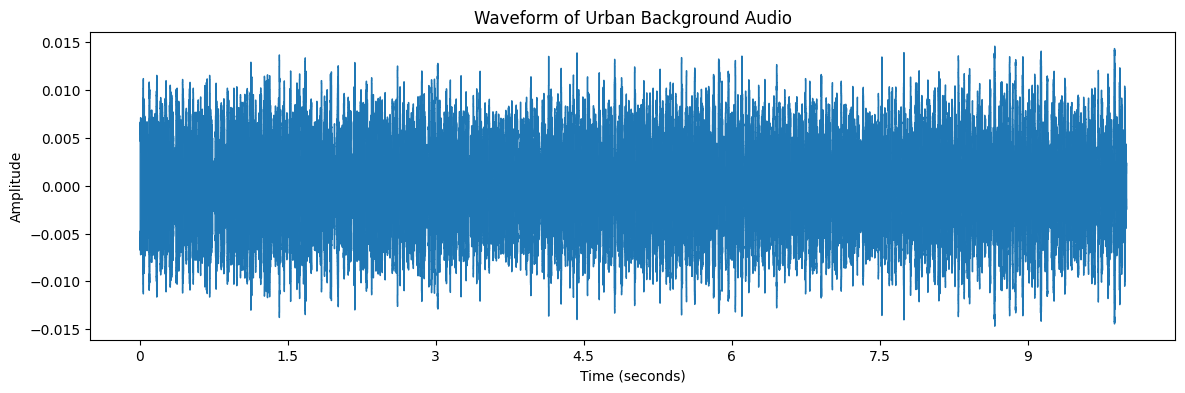

In [ ]:
plt.figure(figsize=(14, 4))

librosa.display.waveshow(y, sr=sr)

plt.title("Waveform of Urban Background Audio")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")

plt.show()

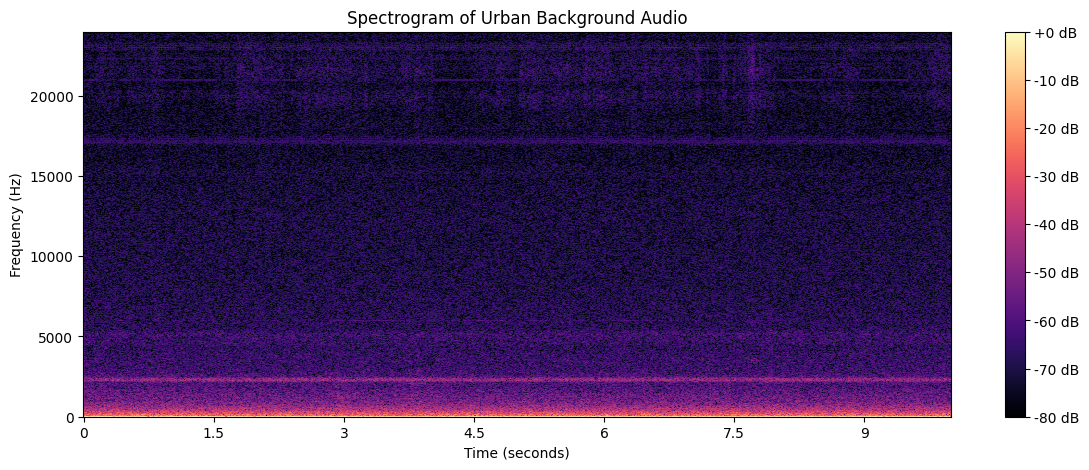

In [ ]:
plt.figure(figsize=(14, 5))

D = librosa.amplitude_to_db(
    np.abs(librosa.stft(y)),
    ref=np.max
)

librosa.display.specshow(
    D,
    sr=sr,
    x_axis="time",
    y_axis="hz"
)

plt.colorbar(format="%+2.0f dB")
plt.title("Spectrogram of Urban Background Audio")
plt.xlabel("Time (seconds)")
plt.ylabel("Frequency (Hz)")

plt.show()

In [ ]:
# Extract basic acoustic features from one audio file

# 1. RMS Energy
rms = librosa.feature.rms(y=y)

# 2. Zero Crossing Rate
zcr = librosa.feature.zero_crossing_rate(y)

# 3. Spectral Centroid
spectral_centroid = librosa.feature.spectral_centroid(
    y=y,
    sr=sr
)

# 4. Spectral Bandwidth
spectral_bandwidth = librosa.feature.spectral_bandwidth(
    y=y,
    sr=sr
)

# 5. Spectral Rolloff
spectral_rolloff = librosa.feature.spectral_rolloff(
    y=y,
    sr=sr
)

# 6. MFCC
mfcc = librosa.feature.mfcc(
    y=y,
    sr=sr,
    n_mfcc=13
)

print("RMS shape:", rms.shape)
print("ZCR shape:", zcr.shape)
print("Spectral Centroid shape:", spectral_centroid.shape)
print("Spectral Bandwidth shape:", spectral_bandwidth.shape)
print("Spectral Rolloff shape:", spectral_rolloff.shape)
print("MFCC shape:", mfcc.shape)

RMS shape: (1, 938)
ZCR shape: (1, 938)
Spectral Centroid shape: (1, 938)
Spectral Bandwidth shape: (1, 938)
Spectral Rolloff shape: (1, 938)
MFCC shape: (13, 938)


In [ ]:
# Convert time-varying features into fixed-size statistics

features = {
    "rms_mean": np.mean(rms),
    "rms_std": np.std(rms),

    "zcr_mean": np.mean(zcr),
    "zcr_std": np.std(zcr),

    "spectral_centroid_mean": np.mean(spectral_centroid),
    "spectral_centroid_std": np.std(spectral_centroid),

    "spectral_bandwidth_mean": np.mean(spectral_bandwidth),
    "spectral_bandwidth_std": np.std(spectral_bandwidth),

    "spectral_rolloff_mean": np.mean(spectral_rolloff),
    "spectral_rolloff_std": np.std(spectral_rolloff)
}

# Add MFCC statistics
for i in range(13):
    features[f"mfcc_{i+1}_mean"] = np.mean(mfcc[i])
    features[f"mfcc_{i+1}_std"] = np.std(mfcc[i])

feature_df = pd.DataFrame([features])

feature_df

,rms_mean,rms_std,zcr_mean,zcr_std,spectral_centroid_mean,spectral_centroid_std,spectral_bandwidth_mean,spectral_bandwidth_std,spectral_rolloff_mean,spectral_rolloff_std,...,mfcc_9_mean,mfcc_9_std,mfcc_10_mean,mfcc_10_std,mfcc_11_mean,mfcc_11_std,mfcc_12_mean,mfcc_12_std,mfcc_13_mean,mfcc_13_std
0,0.005391,0.000827,0.004485,0.004813,2266.424305,360.280526,5171.213957,367.953354,4173.973881,1585.874525,...,7.745785,3.644506,11.090353,3.653559,7.371348,3.856273,-5.361678,3.723129,2.540686,3.469231


In [ ]:
def extract_audio_features(audio_file):

    # Load audio
    y, sr = librosa.load(audio_file, sr=None)

    # Basic features
    rms = librosa.feature.rms(y=y)
    zcr = librosa.feature.zero_crossing_rate(y)

    spectral_centroid = librosa.feature.spectral_centroid(
        y=y,
        sr=sr
    )

    spectral_bandwidth = librosa.feature.spectral_bandwidth(
        y=y,
        sr=sr
    )

    spectral_rolloff = librosa.feature.spectral_rolloff(
        y=y,
        sr=sr
    )

    # MFCC
    mfcc = librosa.feature.mfcc(
        y=y,
        sr=sr,
        n_mfcc=13
    )

    # Fixed-size feature dictionary
    features = {
        "rms_mean": np.mean(rms),
        "rms_std": np.std(rms),

        "zcr_mean": np.mean(zcr),
        "zcr_std": np.std(zcr),

        "spectral_centroid_mean": np.mean(spectral_centroid),
        "spectral_centroid_std": np.std(spectral_centroid),

        "spectral_bandwidth_mean": np.mean(spectral_bandwidth),
        "spectral_bandwidth_std": np.std(spectral_bandwidth),

        "spectral_rolloff_mean": np.mean(spectral_rolloff),
        "spectral_rolloff_std": np.std(spectral_rolloff)
    }

    # MFCC statistics
    for i in range(13):
        features[f"mfcc_{i+1}_mean"] = np.mean(mfcc[i])
        features[f"mfcc_{i+1}_std"] = np.std(mfcc[i])

    return features

In [ ]:
all_audio_files = train_files + valid_files + test_files

feature_rows = []

for i, audio_file in enumerate(all_audio_files):

    features = extract_audio_features(audio_file)

    # Keep file information
    features["audio_file"] = audio_file

    feature_rows.append(features)

    if (i + 1) % 50 == 0:
        print(f"Processed {i + 1}/{len(all_audio_files)} files")

background_features_df = pd.DataFrame(feature_rows)

print("Feature extraction completed!")
print("Rows:", background_features_df.shape[0])
print("Columns:", background_features_df.shape[1])

Processed 50/550 files
Processed 100/550 files
Processed 150/550 files
Processed 200/550 files
Processed 250/550 files
Processed 300/550 files
Processed 350/550 files
Processed 400/550 files
Processed 450/550 files
Processed 500/550 files
Processed 550/550 files
Feature extraction completed!
Rows: 550
Columns: 37


In [ ]:
background_features_df.head()

,rms_mean,rms_std,zcr_mean,zcr_std,spectral_centroid_mean,spectral_centroid_std,spectral_bandwidth_mean,spectral_bandwidth_std,spectral_rolloff_mean,spectral_rolloff_std,...,mfcc_9_std,mfcc_10_mean,mfcc_10_std,mfcc_11_mean,mfcc_11_std,mfcc_12_mean,mfcc_12_std,mfcc_13_mean,mfcc_13_std,audio_file
0,0.005391,0.000827,0.004485,0.004813,2266.424305,360.280526,5171.213957,367.953354,4173.973881,1585.874525,...,3.644506,11.090353,3.653559,7.371348,3.856273,-5.361678,3.723129,2.540686,3.469231,SONYC-Backgrounds/train/20_2017-08-09_02_00.wav
1,0.005726,0.001593,0.005683,0.007279,2332.467082,522.788528,5474.127900,539.576158,4286.538846,2726.304878,...,3.714338,1.627573,3.605353,6.510644,3.535017,1.798764,3.757366,8.142201,3.420375,SONYC-Backgrounds/train/20_2017-04-10_02_00.wav
2,0.003917,0.001397,0.015680,0.012383,3111.251678,658.477752,6117.279127,526.041636,7671.558502,3028.473646,...,3.927197,1.132848,3.814430,6.441899,3.822716,1.391778,3.769145,8.415963,3.889461,SONYC-Backgrounds/train/24_2017-03-19_05_00.wav
3,0.005593,0.000918,0.006112,0.005346,2114.477266,338.483292,5023.581579,361.380179,3172.807836,1372.582085,...,3.640935,2.906440,3.656417,4.286551,3.659319,1.513275,3.749809,6.009285,3.895490,SONYC-Backgrounds/train/20_2017-07-18_04_00.wav
4,0.041296,0.039069,0.001191,0.004084,1102.660428,933.921297,3685.935478,1369.254796,1229.294376,2934.266891,...,3.705337,10.392590,3.576407,8.573660,3.544543,7.781453,3.361622,7.607736,3.342398,SONYC-Backgrounds/train/20_2017-01-09_03_03.wav


In [ ]:
background_features_df.describe()

,rms_mean,rms_std,zcr_mean,zcr_std,spectral_centroid_mean,spectral_centroid_std,spectral_bandwidth_mean,spectral_bandwidth_std,spectral_rolloff_mean,spectral_rolloff_std,...,mfcc_9_mean,mfcc_9_std,mfcc_10_mean,mfcc_10_std,mfcc_11_mean,mfcc_11_std,mfcc_12_mean,mfcc_12_std,mfcc_13_mean,mfcc_13_std
count,550.000000,550.000000,550.000000,550.000000,550.000000,550.000000,550.000000,550.000000,550.000000,550.000000,...,550.000000,550.000000,550.000000,550.000000,550.000000,550.000000,550.000000,550.000000,550.000000,550.000000
mean,0.009827,0.005400,0.008400,0.007170,1994.661132,488.621818,4607.270431,535.891261,3626.670185,1705.923859,...,9.224240,4.140823,3.308332,4.158939,5.998142,4.043236,5.415641,3.984098,6.017332,3.953382
std,0.008254,0.007648,0.004565,0.002445,520.054233,221.222635,780.914474,290.957186,1722.380294,1021.793350,...,3.504193,0.643239,3.981986,0.668628,2.213926,0.561795,3.611747,0.477638,3.034634,0.458627
min,0.003200,0.000693,0.000360,0.001659,521.320324,185.943278,2499.131265,205.894526,182.427705,342.960226,...,-3.146560,2.671919,-8.799034,2.626610,-3.295797,2.673494,-7.782489,2.770589,-4.949582,2.793177
25%,0.005349,0.001062,0.004905,0.005422,1643.457113,322.302656,3945.883702,335.259366,2512.716135,840.860608,...,7.461518,3.738492,1.266748,3.709494,4.746833,3.679231,3.024926,3.655154,4.666298,3.645870
50%,0.006739,0.001766,0.007642,0.006843,1866.985015,432.930369,4540.881653,435.202596,3262.335088,1505.430636,...,9.655279,3.875233,3.026287,3.867505,6.142975,3.832329,5.235412,3.816980,6.458790,3.799213
75%,0.010757,0.005957,0.011218,0.008673,2324.274699,604.305625,5217.919002,639.927459,4442.087137,2401.967204,...,11.413862,4.414519,5.276943,4.533574,7.443244,4.294724,7.973786,4.286615,7.733124,4.181292
max,0.082799,0.043709,0.033576,0.021765,3594.372137,1275.643896,6648.075259,1479.905733,10231.268324,5347.578559,...,17.285458,7.608281,17.128483,8.091051,12.849872,6.376429,14.111923,6.647065,16.639559,6.145834


In [ ]:
# ==========================================
# DATA QUALITY CHECK
# ==========================================

# 1. Missing values
print("Missing values:")
print(background_features_df.isnull().sum().sum())

# 2. Duplicate audio files
print("\nDuplicate audio files:")
print(background_features_df["audio_file"].duplicated().sum())

# 3. Number of unique audio files
print("\nUnique audio files:")
print(background_features_df["audio_file"].nunique())

# 4. Feature columns
feature_columns = [
    col for col in background_features_df.columns
    if col != "audio_file"
]

print("\nNumber of feature columns:")
print(len(feature_columns))

# 5. Infinite values
print("\nInfinite values:")
print(
    np.isinf(
        background_features_df[feature_columns].to_numpy()
    ).sum()
)

Missing values:
0

Duplicate audio files:
0

Unique audio files:
550

Number of feature columns:
36

Infinite values:
0


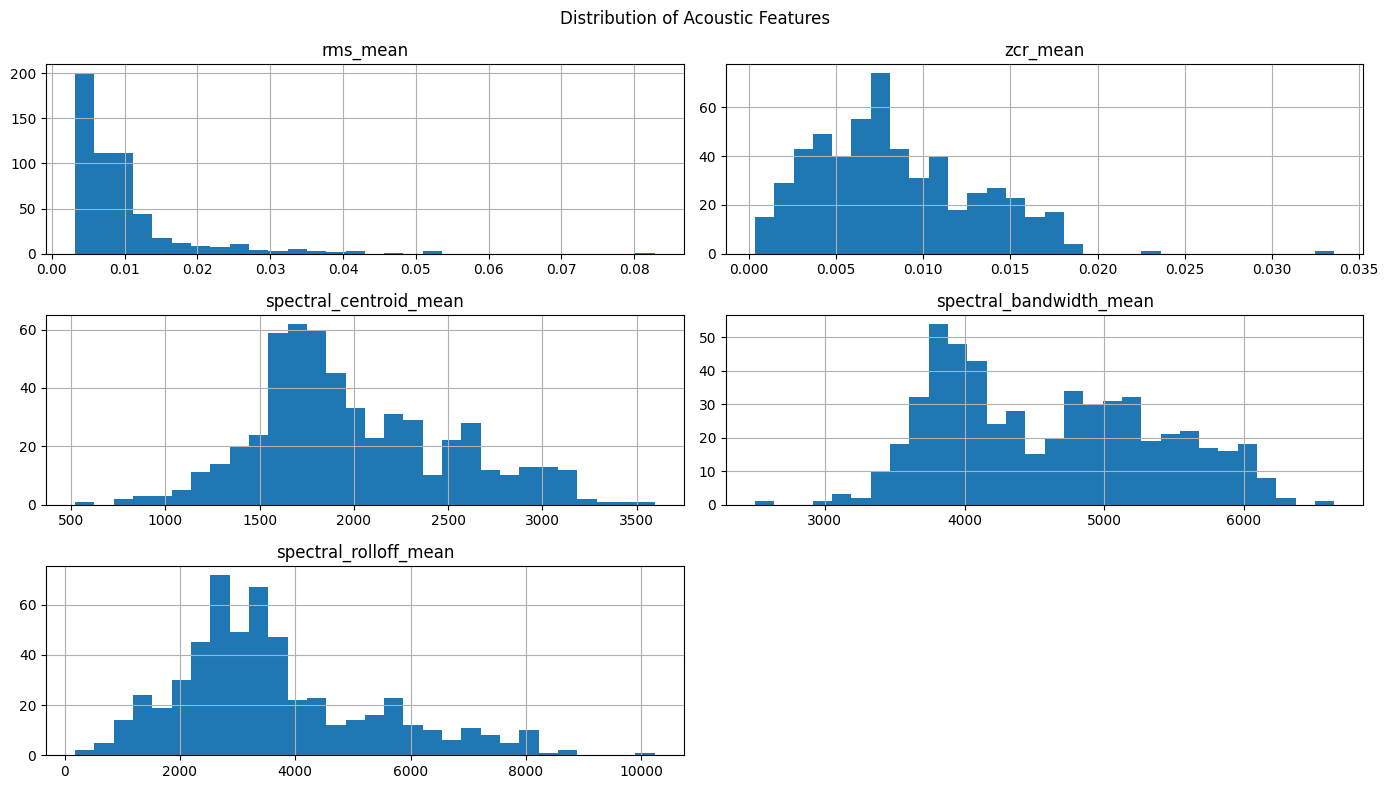

In [ ]:
# Distribution of selected acoustic features

selected_features = [
    "rms_mean",
    "zcr_mean",
    "spectral_centroid_mean",
    "spectral_bandwidth_mean",
    "spectral_rolloff_mean"
]

background_features_df[selected_features].hist(
    figsize=(14, 8),
    bins=30
)

plt.suptitle("Distribution of Acoustic Features")
plt.tight_layout()
plt.show()

In [ ]:
# Separate features from file information

X_background = background_features_df[feature_columns].copy()

print("Feature matrix shape:", X_background.shape)
print("Feature matrix type:", type(X_background))

X_background.head()

Feature matrix shape: (550, 36)
Feature matrix type: <class 'pandas.core.frame.DataFrame'>


,rms_mean,rms_std,zcr_mean,zcr_std,spectral_centroid_mean,spectral_centroid_std,spectral_bandwidth_mean,spectral_bandwidth_std,spectral_rolloff_mean,spectral_rolloff_std,...,mfcc_9_mean,mfcc_9_std,mfcc_10_mean,mfcc_10_std,mfcc_11_mean,mfcc_11_std,mfcc_12_mean,mfcc_12_std,mfcc_13_mean,mfcc_13_std
0,0.005391,0.000827,0.004485,0.004813,2266.424305,360.280526,5171.213957,367.953354,4173.973881,1585.874525,...,7.745785,3.644506,11.090353,3.653559,7.371348,3.856273,-5.361678,3.723129,2.540686,3.469231
1,0.005726,0.001593,0.005683,0.007279,2332.467082,522.788528,5474.127900,539.576158,4286.538846,2726.304878,...,10.316767,3.714338,1.627573,3.605353,6.510644,3.535017,1.798764,3.757366,8.142201,3.420375
2,0.003917,0.001397,0.015680,0.012383,3111.251678,658.477752,6117.279127,526.041636,7671.558502,3028.473646,...,11.026273,3.927197,1.132848,3.814430,6.441899,3.822716,1.391778,3.769145,8.415963,3.889461
3,0.005593,0.000918,0.006112,0.005346,2114.477266,338.483292,5023.581579,361.380179,3172.807836,1372.582085,...,10.688512,3.640935,2.906440,3.656417,4.286551,3.659319,1.513275,3.749809,6.009285,3.895490
4,0.041296,0.039069,0.001191,0.004084,1102.660428,933.921297,3685.935478,1369.254796,1229.294376,2934.266891,...,13.060170,3.705337,10.392590,3.576407,8.573660,3.544543,7.781453,3.361622,7.607736,3.342398


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_background_scaled = scaler.fit_transform(X_background)

print("Scaled feature matrix shape:", X_background_scaled.shape)

Scaled feature matrix shape: (550, 36)


In [ ]:
scaled_df = pd.DataFrame(
    X_background_scaled,
    columns=feature_columns
)

scaled_df.describe().round(2)

,rms_mean,rms_std,zcr_mean,zcr_std,spectral_centroid_mean,spectral_centroid_std,spectral_bandwidth_mean,spectral_bandwidth_std,spectral_rolloff_mean,spectral_rolloff_std,...,mfcc_9_mean,mfcc_9_std,mfcc_10_mean,mfcc_10_std,mfcc_11_mean,mfcc_11_std,mfcc_12_mean,mfcc_12_std,mfcc_13_mean,mfcc_13_std
count,550.00,550.00,550.00,550.00,550.00,550.00,550.00,550.00,550.00,550.00,...,550.00,550.00,550.00,550.00,550.00,550.00,550.00,550.00,550.00,550.00
mean,-0.00,0.00,-0.00,0.00,0.00,-0.00,-0.00,0.00,0.00,0.00,...,0.00,0.00,-0.00,-0.00,-0.00,-0.00,-0.00,0.00,-0.00,0.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,...,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
min,-0.80,-0.62,-1.76,-2.26,-2.84,-1.37,-2.70,-1.14,-2.00,-1.34,...,-3.53,-2.29,-3.04,-2.29,-4.20,-2.44,-3.66,-2.54,-3.62,-2.53
25%,-0.54,-0.57,-0.77,-0.72,-0.68,-0.75,-0.85,-0.69,-0.65,-0.85,...,-0.50,-0.63,-0.51,-0.67,-0.57,-0.65,-0.66,-0.69,-0.45,-0.67
50%,-0.37,-0.48,-0.17,-0.13,-0.25,-0.25,-0.09,-0.35,-0.21,-0.20,...,0.12,-0.41,-0.07,-0.44,0.07,-0.38,-0.05,-0.35,0.15,-0.34
75%,0.11,0.07,0.62,0.62,0.63,0.52,0.78,0.36,0.47,0.68,...,0.63,0.43,0.49,0.56,0.65,0.45,0.71,0.63,0.57,0.50
max,8.85,5.01,5.52,5.98,3.08,3.56,2.62,3.25,3.84,3.57,...,2.30,5.40,3.47,5.89,3.10,4.16,2.41,5.58,3.50,4.78


In [ ]:
# ==========================================
# CREATE TRAIN / VALIDATION / TEST MATRICES
# ==========================================

train_mask = background_features_df["audio_file"].str.contains(
    "/train/"
)

valid_mask = background_features_df["audio_file"].str.contains(
    "/valid/"
)

test_mask = background_features_df["audio_file"].str.contains(
    "/test/"
)

X_train = background_features_df.loc[
    train_mask, feature_columns
]

X_valid = background_features_df.loc[
    valid_mask, feature_columns
]

X_test = background_features_df.loc[
    test_mask, feature_columns
]

print("Training:", X_train.shape)
print("Validation:", X_valid.shape)
print("Test:", X_test.shape)

Training: (330, 36)
Validation: (110, 36)
Test: (110, 36)


In [ ]:
from sklearn.preprocessing import StandardScaler

ml_scaler = StandardScaler()

X_train_scaled = ml_scaler.fit_transform(X_train)
X_valid_scaled = ml_scaler.transform(X_valid)
X_test_scaled = ml_scaler.transform(X_test)

print("Train:", X_train_scaled.shape)
print("Validation:", X_valid_scaled.shape)
print("Test:", X_test_scaled.shape)

Train: (330, 36)
Validation: (110, 36)
Test: (110, 36)


In [ ]:
from sklearn.ensemble import IsolationForest

isolation_model = IsolationForest(
    n_estimators=200,
    contamination="auto",
    random_state=42
)

isolation_model.fit(X_train_scaled)

print("Isolation Forest training completed!")

Isolation Forest training completed!


In [ ]:
# Generate anomaly scores

isolation_train_score = -isolation_model.score_samples(X_train_scaled)
isolation_valid_score = -isolation_model.score_samples(X_valid_scaled)
isolation_test_score = -isolation_model.score_samples(X_test_scaled)

print("Train score range:",
      isolation_train_score.min(),
      "to",
      isolation_train_score.max())

print("Validation score range:",
      isolation_valid_score.min(),
      "to",
      isolation_valid_score.max())

print("Test score range:",
      isolation_test_score.min(),
      "to",
      isolation_test_score.max())

Train score range: 0.3548659879951614 to 0.640185179371765
Validation score range: 0.3886051859972907 to 0.665826647288994
Test score range: 0.398082266090749 to 0.7145021692120525


In [ ]:
isolation_predictions = isolation_model.predict(X_test_scaled)

print("Test predictions:")
print(isolation_predictions)

print("\nPrediction counts:")
print(pd.Series(isolation_predictions).value_counts())

Test predictions:
[-1  1 -1  1 -1 -1 -1  1  1 -1 -1  1 -1  1  1 -1 -1 -1  1 -1  1 -1 -1 -1
 -1  1 -1 -1 -1 -1 -1 -1  1  1  1  1 -1  1 -1 -1  1 -1  1 -1  1  1 -1  1
 -1 -1 -1 -1 -1 -1 -1 -1  1 -1  1 -1  1 -1  1 -1 -1 -1 -1 -1  1  1  1 -1
  1 -1  1 -1 -1 -1  1 -1  1  1  1  1 -1  1  1 -1 -1 -1  1 -1 -1  1  1 -1
  1  1 -1 -1 -1 -1 -1 -1 -1  1  1  1 -1 -1]

Prediction counts:
-1    66
 1    44
Name: count, dtype: int64


In [ ]:
# ==========================================
# INSPECT ISOLATION FOREST SCORE DISTRIBUTION
# ==========================================

print("Training score percentiles:")
print(
    np.percentile(
        isolation_train_score,
        [50, 75, 90, 95, 99]
    )
)

print("\nValidation score percentiles:")
print(
    np.percentile(
        isolation_valid_score,
        [50, 75, 90, 95, 99]
    )
)

print("\nTest score percentiles:")
print(
    np.percentile(
        isolation_test_score,
        [50, 75, 90, 95, 99]
    )
)

Training score percentiles:
[0.40212891 0.4484453  0.49350274 0.53798707 0.62454953]

Validation score percentiles:
[0.57789284 0.61028313 0.63081818 0.6455271  0.65685965]

Test score percentiles:
[0.51717892 0.56305003 0.6039896  0.63959645 0.67348184]


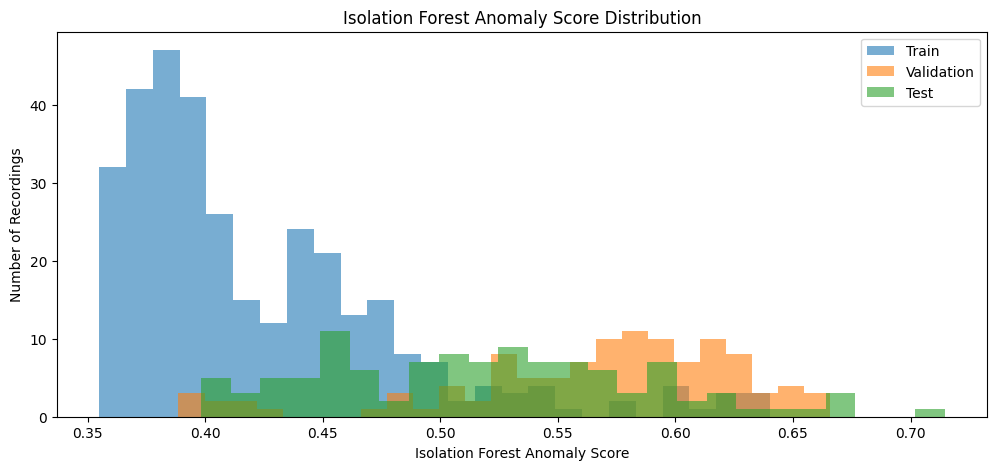

In [ ]:
plt.figure(figsize=(12, 5))

plt.hist(
    isolation_train_score,
    bins=25,
    alpha=0.6,
    label="Train"
)

plt.hist(
    isolation_valid_score,
    bins=25,
    alpha=0.6,
    label="Validation"
)

plt.hist(
    isolation_test_score,
    bins=25,
    alpha=0.6,
    label="Test"
)

plt.xlabel("Isolation Forest Anomaly Score")
plt.ylabel("Number of Recordings")
plt.title("Isolation Forest Anomaly Score Distribution")
plt.legend()

plt.show()

In [ ]:
print("Isolation Forest offset:", isolation_model.offset_)

print(
    "Equivalent anomaly-score threshold:",
    -isolation_model.offset_
)

Isolation Forest offset: -0.5
Equivalent anomaly-score threshold: 0.5


In [ ]:
# ==========================================
# CHECK SENSOR DISTRIBUTION
# ==========================================

background_features_df["sensor_id"] = (
    background_features_df["audio_file"]
    .str.extract(r"/(\d+)_")[0]
    .astype(int)
)

print("Train sensors:")
print(
    sorted(
        background_features_df.loc[
            train_mask, "sensor_id"
        ].unique()
    )
)

print("\nValidation sensors:")
print(
    sorted(
        background_features_df.loc[
            valid_mask, "sensor_id"
        ].unique()
    )
)

print("\nTest sensors:")
print(
    sorted(
        background_features_df.loc[
            test_mask, "sensor_id"
        ].unique()
    )
)

Train sensors:
[np.int64(1), np.int64(20), np.int64(24), np.int64(27)]

Validation sensors:
[np.int64(6), np.int64(14), np.int64(17), np.int64(19), np.int64(37)]

Test sensors:
[np.int64(0), np.int64(2), np.int64(4), np.int64(8), np.int64(31), np.int64(41)]


In [ ]:
train_sensors = set(
    background_features_df.loc[
        train_mask, "sensor_id"
    ]
)

valid_sensors = set(
    background_features_df.loc[
        valid_mask, "sensor_id"
    ]
)

test_sensors = set(
    background_features_df.loc[
        test_mask, "sensor_id"
    ]
)

print("Train ∩ Validation:",
      sorted(train_sensors & valid_sensors))

print("Train ∩ Test:",
      sorted(train_sensors & test_sensors))

print("Validation ∩ Test:",
      sorted(valid_sensors & test_sensors))

Train ∩ Validation: []
Train ∩ Test: []
Validation ∩ Test: []


In [ ]:
from sklearn.neighbors import LocalOutlierFactor

lof_model = LocalOutlierFactor(
    n_neighbors=20,
    contamination="auto",
    novelty=True
)

lof_model.fit(X_train_scaled)

print("LOF training completed!")

LOF training completed!


In [ ]:
lof_train_score = -lof_model.score_samples(X_train_scaled)
lof_valid_score = -lof_model.score_samples(X_valid_scaled)
lof_test_score = -lof_model.score_samples(X_test_scaled)

print("Train score range:",
      lof_train_score.min(),
      "to",
      lof_train_score.max())

print("Validation score range:",
      lof_valid_score.min(),
      "to",
      lof_valid_score.max())

print("Test score range:",
      lof_test_score.min(),
      "to",
      lof_test_score.max())

Train score range: 0.968751497589164 to 2.2209935570020516
Validation score range: 1.1662938612651954 to 2.1842254609810228
Test score range: 1.0123441495610215 to 2.830259842484542


In [ ]:
from sklearn.svm import OneClassSVM

ocsvm_model = OneClassSVM(
    kernel="rbf",
    gamma="scale",
    nu=0.05
)

ocsvm_model.fit(X_train_scaled)

print("One-Class SVM training completed!")

One-Class SVM training completed!


In [ ]:
ocsvm_train_score = -ocsvm_model.score_samples(X_train_scaled)
ocsvm_valid_score = -ocsvm_model.score_samples(X_valid_scaled)
ocsvm_test_score = -ocsvm_model.score_samples(X_test_scaled)

print("Train score range:",
      ocsvm_train_score.min(),
      "to",
      ocsvm_train_score.max())

print("Validation score range:",
      ocsvm_valid_score.min(),
      "to",
      ocsvm_valid_score.max())

print("Test score range:",
      ocsvm_test_score.min(),
      "to",
      ocsvm_test_score.max())

Train score range: -1.6816398132017458 to -1.0699277989769602
Validation score range: -1.2519097718712167 to -0.042572578672815276
Test score range: -1.557835011855114 to -5.467607848030909e-06


In [ ]:
# ==========================================
# COMMON ANOMALY SCORES
# ==========================================

# Isolation Forest
if_train = -isolation_model.decision_function(X_train_scaled)
if_valid = -isolation_model.decision_function(X_valid_scaled)
if_test = -isolation_model.decision_function(X_test_scaled)

# Local Outlier Factor
lof_train = -lof_model.decision_function(X_train_scaled)
lof_valid = -lof_model.decision_function(X_valid_scaled)
lof_test = -lof_model.decision_function(X_test_scaled)

# One-Class SVM
svm_train = -ocsvm_model.decision_function(X_train_scaled)
svm_valid = -ocsvm_model.decision_function(X_valid_scaled)
svm_test = -ocsvm_model.decision_function(X_test_scaled)

print("Isolation Forest test range:",
      if_test.min(), "to", if_test.max())

print("LOF test range:",
      lof_test.min(), "to", lof_test.max())

print("One-Class SVM test range:",
      svm_test.min(), "to", svm_test.max())

Isolation Forest test range: -0.10191773390925102 to 0.21450216921205245
LOF test range: -0.4876558504389785 to 1.330259842484542
One-Class SVM test range: -0.48749531300468907 to 1.070334231242577


In [ ]:
from scipy.stats import percentileofscore

def percentile_scores(train_scores, new_scores):
    return np.array([
        percentileofscore(
            train_scores,
            score,
            kind="rank"
        )
        for score in new_scores
    ])

# Convert scores to percentiles

if_valid_pct = percentile_scores(if_train, if_valid)
if_test_pct = percentile_scores(if_train, if_test)

lof_valid_pct = percentile_scores(lof_train, lof_valid)
lof_test_pct = percentile_scores(lof_train, lof_test)

svm_valid_pct = percentile_scores(svm_train, svm_valid)
svm_test_pct = percentile_scores(svm_train, svm_test)

print("Isolation Forest test percentile range:",
      if_test_pct.min(), "to", if_test_pct.max())

print("LOF test percentile range:",
      lof_test_pct.min(), "to", lof_test_pct.max())

print("SVM test percentile range:",
      svm_test_pct.min(), "to", svm_test_pct.max())

Isolation Forest test percentile range: 46.36363636363637 to 100.0
LOF test percentile range: 22.12121212121212 to 100.0
SVM test percentile range: 2.4242424242424243 to 100.0


In [ ]:
# ==========================================
# CREATE MODEL PERCENTILE TABLE
# ==========================================

test_scores_df = pd.DataFrame({
    "audio_file": background_features_df.loc[
        test_mask, "audio_file"
    ].values,

    "isolation_forest_pct": if_test_pct,

    "lof_pct": lof_test_pct,

    "svm_pct": svm_test_pct
})

test_scores_df.head()

,audio_file,isolation_forest_pct,lof_pct,svm_pct
0,SONYC-Backgrounds/test/31_2017-05-18_05_01.wav,100.000000,93.333333,100.000000
1,SONYC-Backgrounds/test/04_2017-07-19_04_00.wav,81.515152,99.696970,100.000000
2,SONYC-Backgrounds/test/04_2017-04-24_05_00.wav,93.636364,96.666667,100.000000
3,SONYC-Backgrounds/test/02_2017-12-31_04_00.wav,59.090909,87.878788,36.969697
4,SONYC-Backgrounds/test/04_2017-07-02_05_00.wav,97.575758,76.666667,100.000000


In [ ]:
# Correlation between model anomaly scores

print(
    test_scores_df[
        [
            "isolation_forest_pct",
            "lof_pct",
            "svm_pct"
        ]
    ].corr().round(3)
)

                      isolation_forest_pct  lof_pct  svm_pct
isolation_forest_pct                 1.000   -0.055    0.763
lof_pct                             -0.055    1.000    0.187
svm_pct                              0.763    0.187    1.000


In [ ]:
# ==========================================
# TOP ANOMALY CANDIDATES
# ==========================================

test_scores_df["average_pct"] = (
    test_scores_df[
        [
            "isolation_forest_pct",
            "lof_pct",
            "svm_pct"
        ]
    ].mean(axis=1)
)

top_candidates = test_scores_df.sort_values(
    "average_pct",
    ascending=False
).head(15)

top_candidates

,audio_file,isolation_forest_pct,lof_pct,svm_pct,average_pct
51,SONYC-Backgrounds/test/08_2017-05-14_05_00.wav,100.000000,100.000000,100.0,100.000000
30,SONYC-Backgrounds/test/04_2017-04-16_06_00.wav,100.000000,97.575758,100.0,99.191919
101,SONYC-Backgrounds/test/31_2017-04-16_05_00.wav,100.000000,96.666667,100.0,98.888889
77,SONYC-Backgrounds/test/08_2017-05-28_16_00.wav,100.000000,95.757576,100.0,98.585859
61,SONYC-Backgrounds/test/04_2017-06-21_05_00.wav,94.242424,99.696970,100.0,97.979798
0,SONYC-Backgrounds/test/31_2017-05-18_05_01.wav,100.000000,93.333333,100.0,97.777778
29,SONYC-Backgrounds/test/04_2017-06-19_04_02.wav,93.636364,99.696970,100.0,97.777778
95,SONYC-Backgrounds/test/31_2017-05-18_05_00.wav,100.000000,93.030303,100.0,97.676768
41,SONYC-Backgrounds/test/04_2017-07-18_06_00.wav,95.151515,97.272727,100.0,97.474747
16,SONYC-Backgrounds/test/04_2017-06-25_05_01.wav,94.242424,97.878788,100.0,97.373737


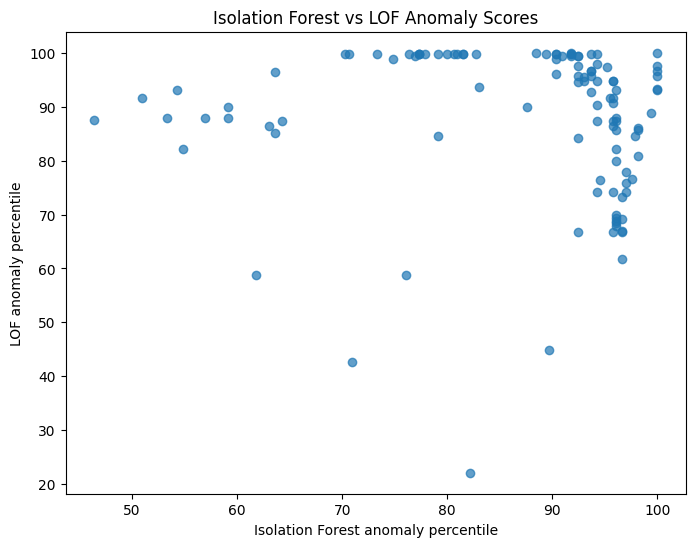

In [ ]:
plt.figure(figsize=(8, 6))

plt.scatter(
    test_scores_df["isolation_forest_pct"],
    test_scores_df["lof_pct"],
    alpha=0.7
)

plt.xlabel("Isolation Forest anomaly percentile")
plt.ylabel("LOF anomaly percentile")
plt.title("Isolation Forest vs LOF Anomaly Scores")

plt.show()

In [ ]:
# ==========================================
# VALIDATION ENSEMBLE
# ==========================================

validation_scores_df = pd.DataFrame({
    "audio_file": background_features_df.loc[
        valid_mask, "audio_file"
    ].values,

    "isolation_forest_pct": if_valid_pct,

    "lof_pct": lof_valid_pct,

    "svm_pct": svm_valid_pct
})

# Equal-weight ensemble
validation_scores_df["ensemble_pct"] = (
    validation_scores_df[
        [
            "isolation_forest_pct",
            "lof_pct",
            "svm_pct"
        ]
    ].mean(axis=1)
)

validation_scores_df.head()

,audio_file,isolation_forest_pct,lof_pct,svm_pct,ensemble_pct
0,SONYC-Backgrounds/valid/14_2017-03-12_22_00.wav,59.696970,95.151515,100.0,84.949495
1,SONYC-Backgrounds/valid/14_2017-05-31_04_00.wav,96.060606,94.848485,100.0,96.969697
2,SONYC-Backgrounds/valid/37_2017-04-14_05_00.wav,96.060606,80.303030,100.0,92.121212
3,SONYC-Backgrounds/valid/19_2017-07-04_06_00.wav,99.696970,93.333333,100.0,97.676768
4,SONYC-Backgrounds/valid/14_2017-05-18_05_00.wav,99.090909,88.787879,100.0,95.959596


In [ ]:
print("Validation ensemble percentiles:")

print(
    np.percentile(
        validation_scores_df["ensemble_pct"],
        [50, 75, 90, 95, 99]
    )
)

Validation ensemble percentiles:
[94.19191919 96.74242424 97.67676768 98.03535354 98.85252525]


In [ ]:
# ==========================================
# MODEL CONSENSUS
# ==========================================

validation_scores_df["models_above_90"] = (
    validation_scores_df[
        [
            "isolation_forest_pct",
            "lof_pct",
            "svm_pct"
        ]
    ] >= 90
).sum(axis=1)

print(
    validation_scores_df["models_above_90"]
    .value_counts()
    .sort_index()
)

models_above_90
0     3
1     5
2    66
3    36
Name: count, dtype: int64


In [ ]:
validation_top = validation_scores_df.sort_values(
    "ensemble_pct",
    ascending=False
).head(15)

validation_top

,audio_file,isolation_forest_pct,lof_pct,svm_pct,ensemble_pct,models_above_90
56,SONYC-Backgrounds/valid/19_2017-05-27_06_00.wav,100.000000,98.181818,100.0,99.393939,3
74,SONYC-Backgrounds/valid/19_2017-06-15_06_00.wav,100.000000,96.666667,100.0,98.888889,3
38,SONYC-Backgrounds/valid/14_2017-07-09_13_00.wav,95.757576,99.696970,100.0,98.484848,3
69,SONYC-Backgrounds/valid/14_2017-05-14_17_00.wav,95.757576,98.787879,100.0,98.181818,3
103,SONYC-Backgrounds/valid/14_2017-04-22_06_00.wav,95.757576,98.787879,100.0,98.181818,3
33,SONYC-Backgrounds/valid/19_2017-06-11_06_00.wav,100.000000,94.242424,100.0,98.080808,3
39,SONYC-Backgrounds/valid/14_2017-07-25_19_00.wav,94.242424,99.696970,100.0,97.979798,3
19,SONYC-Backgrounds/valid/37_2017-06-09_05_00.wav,94.242424,99.696970,100.0,97.979798,3
58,SONYC-Backgrounds/valid/14_2017-07-27_05_00.wav,94.242424,99.696970,100.0,97.979798,3
21,SONYC-Backgrounds/valid/14_2017-04-22_07_00.wav,93.636364,99.696970,100.0,97.777778,3


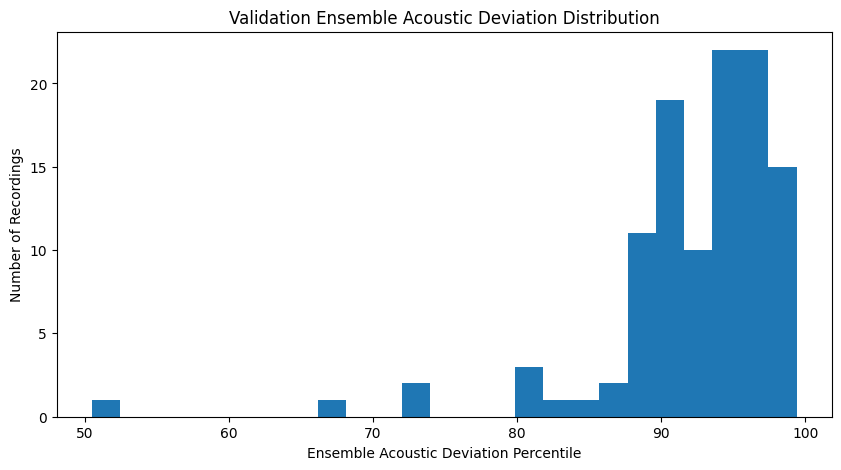

In [ ]:
plt.figure(figsize=(10, 5))

plt.hist(
    validation_scores_df["ensemble_pct"],
    bins=25
)

plt.xlabel("Ensemble Acoustic Deviation Percentile")
plt.ylabel("Number of Recordings")
plt.title("Validation Ensemble Acoustic Deviation Distribution")

plt.show()

In [ ]:
# ==========================================
# VALIDATION DEVIATION LEVELS
# ==========================================

def deviation_level(score):
    if score >= 98.82:
        return "Extreme Deviation"
    elif score >= 97.73:
        return "High Deviation"
    elif score >= 97.27:
        return "Moderate Deviation"
    else:
        return "Normal Variation"


validation_scores_df["deviation_level"] = (
    validation_scores_df["ensemble_pct"]
    .apply(deviation_level)
)

print(
    validation_scores_df["deviation_level"]
    .value_counts()
)

deviation_level
Normal Variation      89
Moderate Deviation    11
High Deviation         8
Extreme Deviation      2
Name: count, dtype: int64


In [ ]:
validation_scores_df[
    [
        "ensemble_pct",
        "models_above_90",
        "deviation_level"
    ]
].describe(include="all")

,ensemble_pct,models_above_90,deviation_level
count,110.000000,110.000000,110
unique,NaN,NaN,4
top,NaN,NaN,Normal Variation
freq,NaN,NaN,89
mean,92.305785,2.227273,NaN
std,6.774235,0.658872,NaN
min,50.505051,0.000000,NaN
25%,90.303030,2.000000,NaN
50%,94.191919,2.000000,NaN
75%,96.742424,3.000000,NaN


In [ ]:
validation_scores_df[
    [
        "audio_file",
        "ensemble_pct",
        "models_above_90",
        "deviation_level"
    ]
].sort_values(
    "ensemble_pct",
    ascending=False
).head(15)

,audio_file,ensemble_pct,models_above_90,deviation_level
56,SONYC-Backgrounds/valid/19_2017-05-27_06_00.wav,99.393939,3,Extreme Deviation
74,SONYC-Backgrounds/valid/19_2017-06-15_06_00.wav,98.888889,3,Extreme Deviation
38,SONYC-Backgrounds/valid/14_2017-07-09_13_00.wav,98.484848,3,High Deviation
69,SONYC-Backgrounds/valid/14_2017-05-14_17_00.wav,98.181818,3,High Deviation
103,SONYC-Backgrounds/valid/14_2017-04-22_06_00.wav,98.181818,3,High Deviation
33,SONYC-Backgrounds/valid/19_2017-06-11_06_00.wav,98.080808,3,High Deviation
39,SONYC-Backgrounds/valid/14_2017-07-25_19_00.wav,97.979798,3,High Deviation
19,SONYC-Backgrounds/valid/37_2017-06-09_05_00.wav,97.979798,3,High Deviation
58,SONYC-Backgrounds/valid/14_2017-07-27_05_00.wav,97.979798,3,High Deviation
21,SONYC-Backgrounds/valid/14_2017-04-22_07_00.wav,97.777778,3,High Deviation


In [ ]:
def extract_enhanced_audio_features(audio_file):

    # Load audio
    y, sr = librosa.load(audio_file, sr=None)

    # ------------------------------------------
    # Frame-level acoustic features
    # ------------------------------------------

    rms = librosa.feature.rms(y=y)[0]

    zcr = librosa.feature.zero_crossing_rate(y)[0]

    spectral_centroid = librosa.feature.spectral_centroid(
        y=y,
        sr=sr
    )[0]

    spectral_bandwidth = librosa.feature.spectral_bandwidth(
        y=y,
        sr=sr
    )[0]

    spectral_rolloff = librosa.feature.spectral_rolloff(
        y=y,
        sr=sr
    )[0]

    # ------------------------------------------
    # Helper function
    # ------------------------------------------

    def statistics(values):

        return {
            "mean": np.mean(values),
            "std": np.std(values),
            "p10": np.percentile(values, 10),
            "p25": np.percentile(values, 25),
            "median": np.percentile(values, 50),
            "p75": np.percentile(values, 75),
            "p90": np.percentile(values, 90)
        }

    features = {}

    # ------------------------------------------
    # Acoustic statistics
    # ------------------------------------------

    acoustic_features = {
        "rms": rms,
        "zcr": zcr,
        "spectral_centroid": spectral_centroid,
        "spectral_bandwidth": spectral_bandwidth,
        "spectral_rolloff": spectral_rolloff
    }

    for name, values in acoustic_features.items():

        stats = statistics(values)

        for stat_name, stat_value in stats.items():

            features[f"{name}_{stat_name}"] = stat_value

    # ------------------------------------------
    # MFCC
    # ------------------------------------------

    mfcc = librosa.feature.mfcc(
        y=y,
        sr=sr,
        n_mfcc=13
    )

    for i in range(13):

        stats = statistics(mfcc[i])

        for stat_name, stat_value in stats.items():

            features[
                f"mfcc_{i+1}_{stat_name}"
            ] = stat_value

    return features

In [ ]:
test_features = extract_enhanced_audio_features(
    train_files[0]
)

print("Number of features:", len(test_features))

pd.DataFrame([test_features]).head()

Number of features: 126


,rms_mean,rms_std,rms_p10,rms_p25,rms_median,rms_p75,rms_p90,zcr_mean,zcr_std,zcr_p10,...,mfcc_12_median,mfcc_12_p75,mfcc_12_p90,mfcc_13_mean,mfcc_13_std,mfcc_13_p10,mfcc_13_p25,mfcc_13_median,mfcc_13_p75,mfcc_13_p90
0,0.005391,0.000827,0.004358,0.004791,0.005372,0.00595,0.006488,0.004485,0.004813,0.0,...,-5.392594,-2.881242,-0.641207,2.540686,3.469231,-2.058549,0.353159,2.575907,4.830532,6.918661


In [ ]:
# ==========================================
# BUILD ENHANCED FEATURE DATASET
# ==========================================

import pandas as pd
import os
from tqdm import tqdm

enhanced_rows = []

all_audio_files = (
    train_files +
    valid_files +
    test_files
)

for i, audio_file in enumerate(tqdm(all_audio_files)):

    try:

        # Extract 126 acoustic features
        features = extract_enhanced_audio_features(audio_file)

        # Store file path
        features["audio_file"] = audio_file

        # Store split information
        if "/train/" in audio_file:
            features["split"] = "train"

        elif "/valid/" in audio_file:
            features["split"] = "valid"

        else:
            features["split"] = "test"

        enhanced_rows.append(features)

    except Exception as e:

        print(
            f"Error processing {audio_file}:",
            e
        )

print("Completed feature extraction!")

enhanced_background_features_df = pd.DataFrame(
    enhanced_rows
)

print(
    "Dataset Shape:",
    enhanced_background_features_df.shape
)

enhanced_background_features_df.head()

100%|██████████| 550/550 [01:48<00:00,  5.06it/s]

Completed feature extraction!
Dataset Shape: (550, 128)


,rms_mean,rms_std,rms_p10,rms_p25,rms_median,rms_p75,rms_p90,zcr_mean,zcr_std,zcr_p10,...,mfcc_12_p90,mfcc_13_mean,mfcc_13_std,mfcc_13_p10,mfcc_13_p25,mfcc_13_median,mfcc_13_p75,mfcc_13_p90,audio_file,split
0,0.005391,0.000827,0.004358,0.004791,0.005372,0.005950,0.006488,0.004485,0.004813,0.0,...,-0.641207,2.540686,3.469231,-2.058549,0.353159,2.575907,4.830532,6.918661,SONYC-Backgrounds/train/20_2017-08-09_02_00.wav,train
1,0.005726,0.001593,0.003803,0.004661,0.005609,0.006563,0.007599,0.005683,0.007279,0.0,...,6.565838,8.142201,3.420375,3.902697,5.688372,7.977226,10.583901,12.656203,SONYC-Backgrounds/train/20_2017-04-10_02_00.wav,train
2,0.003917,0.001397,0.002278,0.002860,0.003764,0.004776,0.005868,0.015680,0.012383,0.0,...,6.189547,8.415963,3.889461,3.597066,5.796831,8.415971,11.021526,13.482717,SONYC-Backgrounds/train/24_2017-03-19_05_00.wav,train
3,0.005593,0.000918,0.004418,0.004992,0.005569,0.006173,0.006812,0.006112,0.005346,0.0,...,6.272458,6.009285,3.895490,1.122741,3.316527,6.127908,8.634059,10.888298,SONYC-Backgrounds/train/20_2017-07-18_04_00.wav,train
4,0.041296,0.039069,0.007180,0.016209,0.029088,0.051424,0.088345,0.001191,0.004084,0.0,...,12.038109,7.607736,3.342398,3.302219,5.351817,7.576762,9.767789,12.007750,SONYC-Backgrounds/train/20_2017-01-09_03_03.wav,train


In [ ]:
# ==========================================
# DATA QUALITY CHECK
# ==========================================

print("Missing values:",
      enhanced_background_features_df.isnull().sum().sum())

print("Duplicate recordings:",
      enhanced_background_features_df["audio_file"].duplicated().sum())

print("Unique recordings:",
      enhanced_background_features_df["audio_file"].nunique())

print("\nSplit distribution:")

print(
    enhanced_background_features_df["split"]
    .value_counts()
)

Missing values: 0
Duplicate recordings: 0
Unique recordings: 550

Split distribution:
split
train    330
valid    110
test     110
Name: count, dtype: int64


In [ ]:
# ==========================================
# EXTRACT METADATA FROM FILE NAME
# ==========================================

file_name = (
    enhanced_background_features_df["audio_file"]
    .apply(os.path.basename)
)

# Sensor ID
enhanced_background_features_df["sensor_id"] = (
    file_name.str.extract(r"^(\d+)_")[0]
    .astype(int)
)

# Date
enhanced_background_features_df["date"] = (
    file_name.str.extract(
        r"_(\d{4}-\d{2}-\d{2})_"
    )[0]
)

enhanced_background_features_df["date"] = pd.to_datetime(
    enhanced_background_features_df["date"]
)

# Calendar information
enhanced_background_features_df["year"] = (
    enhanced_background_features_df["date"].dt.year
)

enhanced_background_features_df["month"] = (
    enhanced_background_features_df["date"].dt.month
)

enhanced_background_features_df["day"] = (
    enhanced_background_features_df["date"].dt.day
)

# Hour
enhanced_background_features_df["hour"] = (
    file_name.str.extract(
        r"_(\d{2})_\d{2}\.wav$"
    )[0]
    .astype(int)
)

# Display metadata
enhanced_background_features_df[
    [
        "audio_file",
        "sensor_id",
        "date",
        "year",
        "month",
        "day",
        "hour",
        "split"
    ]
].head(10)

,audio_file,sensor_id,date,year,month,day,hour,split
0,SONYC-Backgrounds/train/20_2017-08-09_02_00.wav,20,2017-08-09,2017,8,9,2,train
1,SONYC-Backgrounds/train/20_2017-04-10_02_00.wav,20,2017-04-10,2017,4,10,2,train
2,SONYC-Backgrounds/train/24_2017-03-19_05_00.wav,24,2017-03-19,2017,3,19,5,train
3,SONYC-Backgrounds/train/20_2017-07-18_04_00.wav,20,2017-07-18,2017,7,18,4,train
4,SONYC-Backgrounds/train/20_2017-01-09_03_03.wav,20,2017-01-09,2017,1,9,3,train
5,SONYC-Backgrounds/train/20_2017-07-11_03_00.wav,20,2017-07-11,2017,7,11,3,train
6,SONYC-Backgrounds/train/20_2017-06-26_01_00.wav,20,2017-06-26,2017,6,26,1,train
7,SONYC-Backgrounds/train/24_2017-05-11_03_00.wav,24,2017-05-11,2017,5,11,3,train
8,SONYC-Backgrounds/train/20_2017-07-13_04_01.wav,20,2017-07-13,2017,7,13,4,train
9,SONYC-Backgrounds/train/20_2017-06-25_03_00.wav,20,2017-06-25,2017,6,25,3,train


In [ ]:
print("Unique sensors:")
print(
    sorted(
        enhanced_background_features_df["sensor_id"].unique()
    )
)

print("\nHour range:")
print(
    enhanced_background_features_df["hour"].min(),
    "to",
    enhanced_background_features_df["hour"].max()
)

print("\nDate range:")
print(
    enhanced_background_features_df["date"].min(),
    "to",
    enhanced_background_features_df["date"].max()
)

Unique sensors:
[np.int64(0), np.int64(1), np.int64(2), np.int64(4), np.int64(6), np.int64(8), np.int64(14), np.int64(17), np.int64(19), np.int64(20), np.int64(24), np.int64(27), np.int64(31), np.int64(37), np.int64(41)]

Hour range:
0 to 23

Date range:
2017-01-02 00:00:00 to 2017-12-31 00:00:00


In [ ]:
# ==========================================
# SAVE MASTER ENHANCED DATASET
# ==========================================

enhanced_background_features_df.to_csv(
    "enhanced_acoustic_features.csv",
    index=False
)

print("Master dataset saved successfully!")

Master dataset saved successfully!


In [ ]:
import os

print(
    "File exists:",
    os.path.exists("enhanced_acoustic_features.csv")
)

File exists: True


In [ ]:
# ==========================================
# FEATURE VARIABILITY ANALYSIS
# ==========================================

# Acoustic feature columns only
metadata_columns = [
    "audio_file",
    "split",
    "sensor_id",
    "date",
    "year",
    "month",
    "day",
    "hour"
]

enhanced_feature_columns = [
    col for col in enhanced_background_features_df.columns
    if col not in metadata_columns
]

# Calculate standard deviation
feature_variability = (
    enhanced_background_features_df[
        enhanced_feature_columns
    ]
    .std()
    .sort_values(ascending=False)
)

print("Number of acoustic features:",
      len(enhanced_feature_columns))

print("\nTop 20 most variable features:")

print(
    feature_variability.head(20)
)

# Bottom 20 least variable features

print("\nBottom 20 least variable features:")

print(
    feature_variability.tail(20)
)

Number of acoustic features: 126

Top 20 most variable features:
spectral_rolloff_p90         2688.794027
spectral_rolloff_p75         2259.176182
spectral_rolloff_median      1927.110963
spectral_rolloff_mean        1722.380294
spectral_rolloff_p25         1610.307470
spectral_rolloff_p10         1321.424361
spectral_rolloff_std         1021.793350
spectral_bandwidth_p90        889.642176
spectral_bandwidth_p10        850.698907
spectral_bandwidth_p75        822.937623
spectral_bandwidth_p25        810.539001
spectral_bandwidth_median     790.375967
spectral_bandwidth_mean       780.914474
spectral_centroid_p90         635.061360
spectral_centroid_p75         565.950340
spectral_centroid_median      540.026667
spectral_centroid_p25         536.641819
spectral_centroid_p10         532.506160
spectral_centroid_mean        520.054233
spectral_bandwidth_std        290.957186
dtype: float64

Bottom 20 least variable features:
mfcc_10_std    0.668628
mfcc_7_std     0.668348
mfcc_9_std     0

In [ ]:
# ==========================================
# FEATURE CORRELATION ANALYSIS
# ==========================================

correlation_matrix = (
    enhanced_background_features_df[
        enhanced_feature_columns
    ]
    .corr()
)

# Get absolute correlations
corr_pairs = (
    correlation_matrix
    .abs()
    .unstack()
    .sort_values(ascending=False)
)

# Remove self-correlations
corr_pairs = corr_pairs[
    corr_pairs < 0.999999
]

print("Top 20 feature correlations:")

print(
    corr_pairs.head(20)
)

Top 20 feature correlations:
mfcc_2_mean    mfcc_2_median    0.999856
mfcc_2_median  mfcc_2_mean      0.999856
mfcc_1_mean    mfcc_1_median    0.999796
mfcc_1_median  mfcc_1_mean      0.999796
mfcc_1_p10     mfcc_1_p25       0.999776
mfcc_1_p25     mfcc_1_p10       0.999776
mfcc_3_mean    mfcc_3_median    0.999681
mfcc_3_median  mfcc_3_mean      0.999681
mfcc_1_median  mfcc_1_p25       0.999464
mfcc_1_p25     mfcc_1_median    0.999464
mfcc_3_p90     mfcc_3_p75       0.999452
mfcc_3_p75     mfcc_3_p90       0.999452
mfcc_2_p75     mfcc_2_mean      0.999450
mfcc_2_mean    mfcc_2_p75       0.999450
mfcc_2_p25     mfcc_2_median    0.999436
mfcc_2_median  mfcc_2_p25       0.999436
mfcc_7_median  mfcc_7_mean      0.999419
mfcc_7_mean    mfcc_7_median    0.999419
mfcc_1_mean    mfcc_1_p75       0.999411
mfcc_1_p75     mfcc_1_mean      0.999411
dtype: float64


In [ ]:
# ==========================================
# PCA ANALYSIS
# ==========================================

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Extract features
X_enhanced = enhanced_background_features_df[
    enhanced_feature_columns
]

# Scale
pca_scaler = StandardScaler()

X_enhanced_scaled = pca_scaler.fit_transform(
    X_enhanced
)

# PCA
pca = PCA(n_components=2)

X_pca = pca.fit_transform(
    X_enhanced_scaled
)

print("PCA shape:", X_pca.shape)

print(
    "Explained variance ratio:",
    pca.explained_variance_ratio_
)

print(
    "Total variance explained:",
    pca.explained_variance_ratio_.sum()
)

PCA shape: (550, 2)
Explained variance ratio: [0.36772081 0.19186675]
Total variance explained: 0.5595875575019831


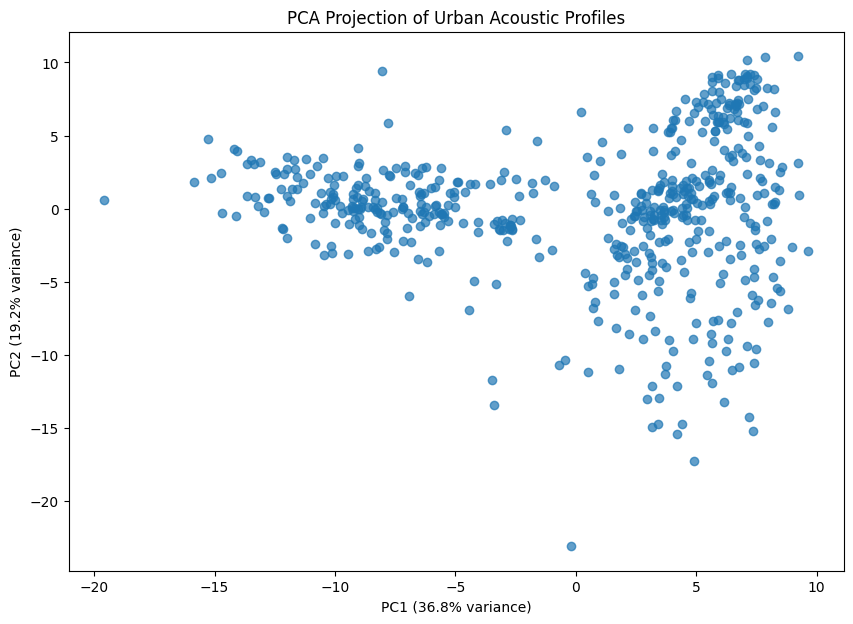

In [ ]:
# ==========================================
# PCA VISUALIZATION
# ==========================================

plt.figure(figsize=(10, 7))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    alpha=0.7
)

plt.xlabel(
    f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)"
)

plt.ylabel(
    f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)"
)

plt.title(
    "PCA Projection of Urban Acoustic Profiles"
)

plt.show()

In [ ]:
# ==========================================
# PREPARE ENHANCED ML MATRICES
# ==========================================

enhanced_train_mask = (
    enhanced_background_features_df["split"] == "train"
)

enhanced_valid_mask = (
    enhanced_background_features_df["split"] == "valid"
)

enhanced_test_mask = (
    enhanced_background_features_df["split"] == "test"
)

X_enhanced_train = enhanced_background_features_df.loc[
    enhanced_train_mask,
    enhanced_feature_columns
]

X_enhanced_valid = enhanced_background_features_df.loc[
    enhanced_valid_mask,
    enhanced_feature_columns
]

X_enhanced_test = enhanced_background_features_df.loc[
    enhanced_test_mask,
    enhanced_feature_columns
]

print("Train:", X_enhanced_train.shape)
print("Validation:", X_enhanced_valid.shape)
print("Test:", X_enhanced_test.shape)

Train: (330, 126)
Validation: (110, 126)
Test: (110, 126)


In [ ]:
# ==========================================
# SCALE ENHANCED FEATURES
# ==========================================

enhanced_scaler = StandardScaler()

X_enhanced_train_scaled = (
    enhanced_scaler.fit_transform(
        X_enhanced_train
    )
)

X_enhanced_valid_scaled = (
    enhanced_scaler.transform(
        X_enhanced_valid
    )
)

X_enhanced_test_scaled = (
    enhanced_scaler.transform(
        X_enhanced_test
    )
)

print(
    "Train:",
    X_enhanced_train_scaled.shape
)

print(
    "Validation:",
    X_enhanced_valid_scaled.shape
)

print(
    "Test:",
    X_enhanced_test_scaled.shape
)

Train: (330, 126)
Validation: (110, 126)
Test: (110, 126)


In [ ]:
# ==========================================
# PCA EXPLAINED VARIANCE
# ==========================================

pca_full = PCA()

X_train_pca_full = pca_full.fit_transform(
    X_enhanced_train_scaled
)

cumulative_variance = np.cumsum(
    pca_full.explained_variance_ratio_
)

for threshold in [0.90, 0.95, 0.99]:

    components_needed = (
        np.argmax(
            cumulative_variance >= threshold
        ) + 1
    )

    print(
        f"{threshold*100:.0f}% variance:",
        components_needed,
        "components"
    )

90% variance: 9 components
95% variance: 13 components
99% variance: 25 components


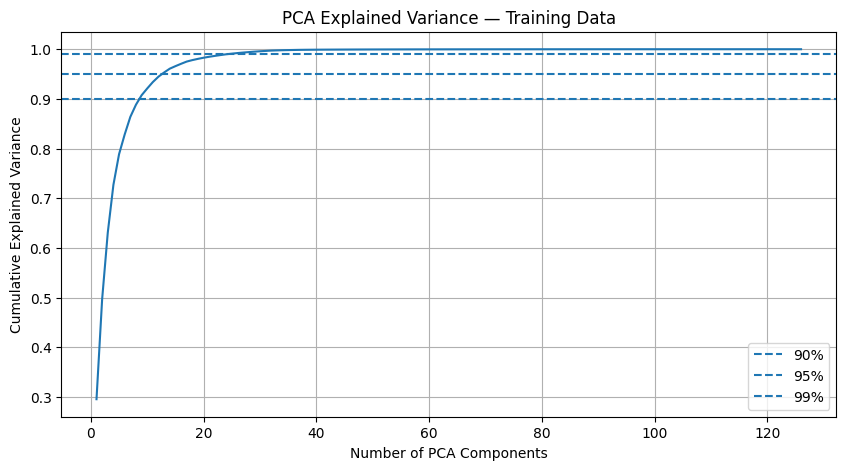

In [ ]:
plt.figure(figsize=(10, 5))

plt.plot(
    range(1, len(cumulative_variance) + 1),
    cumulative_variance
)

plt.axhline(
    0.90,
    linestyle="--",
    label="90%"
)

plt.axhline(
    0.95,
    linestyle="--",
    label="95%"
)

plt.axhline(
    0.99,
    linestyle="--",
    label="99%"
)

plt.xlabel("Number of PCA Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance — Training Data")
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
# ==========================================
# CREATE 95% PCA REPRESENTATION
# ==========================================

pca_95 = PCA(n_components=13)

# IMPORTANT:
# Fit PCA ONLY on training data

X_train_pca = pca_95.fit_transform(
    X_enhanced_train_scaled
)

# Transform validation and test
X_valid_pca = pca_95.transform(
    X_enhanced_valid_scaled
)

X_test_pca = pca_95.transform(
    X_enhanced_test_scaled
)

print("Training PCA shape:", X_train_pca.shape)
print("Validation PCA shape:", X_valid_pca.shape)
print("Test PCA shape:", X_test_pca.shape)

print(
    "\nVariance retained:",
    pca_95.explained_variance_ratio_.sum()
)

Training PCA shape: (330, 13)
Validation PCA shape: (110, 13)
Test PCA shape: (110, 13)

Variance retained: 0.9532421132551279


In [ ]:
# ==========================================
# PCA COMPONENT INTERPRETATION
# ==========================================

pca_loadings = pd.DataFrame(
    pca_95.components_.T,
    index=enhanced_feature_columns,
    columns=[
        f"PC{i+1}"
        for i in range(13)
    ]
)

pca_loadings.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13
rms_mean,-0.139340,-0.011338,-0.039795,-0.028336,-0.142888,0.045070,-0.021706,-0.000211,0.032615,0.117983,0.032951,-0.065092,-0.081650
rms_std,-0.136980,-0.029660,-0.024981,-0.031133,-0.126451,0.087757,-0.061254,-0.110771,-0.031851,0.028441,0.016516,-0.078421,-0.014809
rms_p10,-0.105433,0.042563,-0.060070,0.012166,-0.094717,-0.069541,0.038473,0.179502,0.137548,0.218740,0.086174,-0.015874,-0.171154
rms_p25,-0.122124,0.015643,-0.052370,-0.011824,-0.123745,-0.020530,0.023206,0.132311,0.111045,0.207639,0.068958,-0.041188,-0.135502
rms_median,-0.133060,-0.003888,-0.044554,-0.026765,-0.143788,0.020065,-0.001403,0.060414,0.065805,0.158070,0.037520,-0.056379,-0.112604


In [ ]:
# ==========================================
# TOP FEATURES CONTRIBUTING TO PCA COMPONENTS
# ==========================================

for component in [
    "PC1",
    "PC2",
    "PC3",
    "PC4",
    "PC5"
]:

    print("\n", component)

    print(
        pca_loadings[component]
        .abs()
        .sort_values(ascending=False)
        .head(10)
    )


 PC1
spectral_centroid_p25       0.154520
spectral_centroid_median    0.153137
spectral_centroid_p10       0.151683
spectral_centroid_mean      0.149354
spectral_bandwidth_p10      0.148240
spectral_bandwidth_p25      0.146900
spectral_rolloff_median     0.145742
zcr_p75                     0.143455
spectral_rolloff_p25        0.143242
zcr_mean                    0.139456
Name: PC1, dtype: float64

 PC2
mfcc_10_std    0.156479
mfcc_8_std     0.156369
mfcc_11_std    0.153486
mfcc_6_std     0.151561
mfcc_7_p10     0.148899
mfcc_3_p10     0.145358
mfcc_9_std     0.143557
mfcc_7_p25     0.143500
mfcc_13_std    0.143000
mfcc_12_std    0.142749
Name: PC2, dtype: float64

 PC3
mfcc_9_p75        0.195447
mfcc_9_mean       0.195096
mfcc_9_median     0.194998
mfcc_9_p25        0.194653
mfcc_9_p90        0.194606
mfcc_9_p10        0.192927
mfcc_10_p90       0.168170
mfcc_10_p75       0.166848
mfcc_10_median    0.163799
mfcc_10_mean      0.163647
Name: PC3, dtype: float64

 PC4
mfcc_6_p10       0

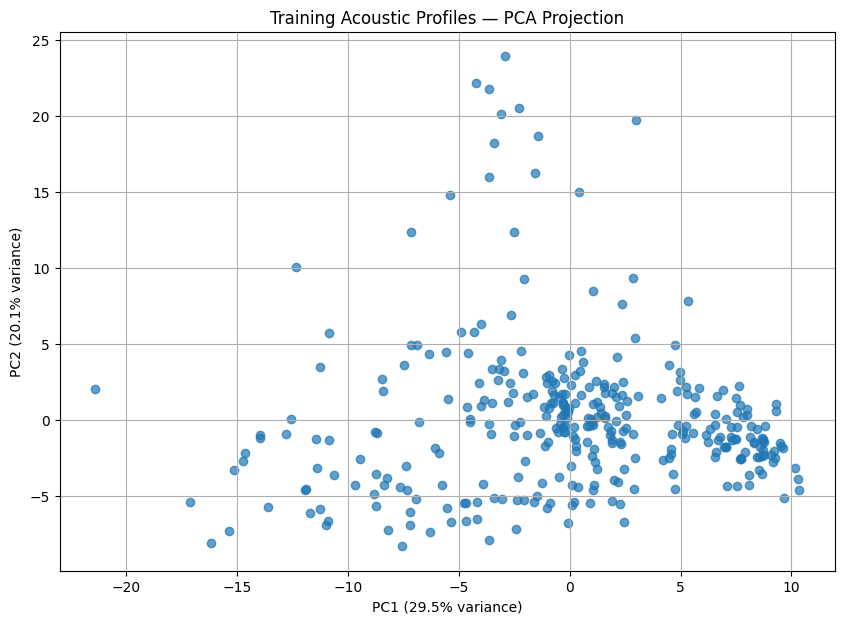

In [ ]:
# ==========================================
# PCA 2D VISUALIZATION
# ==========================================

plt.figure(figsize=(10, 7))

plt.scatter(
    X_train_pca[:, 0],
    X_train_pca[:, 1],
    alpha=0.7
)

plt.xlabel(
    f"PC1 ({pca_95.explained_variance_ratio_[0]*100:.1f}% variance)"
)

plt.ylabel(
    f"PC2 ({pca_95.explained_variance_ratio_[1]*100:.1f}% variance)"
)

plt.title(
    "Training Acoustic Profiles — PCA Projection"
)

plt.grid(True)

plt.show()

In [ ]:
# ==========================================
# ENHANCED ISOLATION FOREST
# ==========================================

from sklearn.ensemble import IsolationForest

enhanced_if_model = IsolationForest(
    n_estimators=300,
    contamination="auto",
    random_state=42
)

enhanced_if_model.fit(
    X_enhanced_train_scaled
)

print("Enhanced Isolation Forest trained!")

# ==========================================
# ENHANCED IF SCORES
# ==========================================

enhanced_if_train = (
    -enhanced_if_model.decision_function(
        X_enhanced_train_scaled
    )
)

enhanced_if_valid = (
    -enhanced_if_model.decision_function(
        X_enhanced_valid_scaled
    )
)

enhanced_if_test = (
    -enhanced_if_model.decision_function(
        X_enhanced_test_scaled
    )
)

print(
    "Train:",
    enhanced_if_train.min(),
    "to",
    enhanced_if_train.max()
)

print(
    "Validation:",
    enhanced_if_valid.min(),
    "to",
    enhanced_if_valid.max()
)

print(
    "Test:",
    enhanced_if_test.min(),
    "to",
    enhanced_if_test.max()
)

Enhanced Isolation Forest trained!
Train: -0.13690875542216585 to 0.12577912411003067
Validation: -0.08502319419002469 to 0.15404914846937745
Test: -0.09774270468700008 to 0.15884626990051443


In [ ]:
enhanced_if_valid_pct = percentile_scores(
    enhanced_if_train,
    enhanced_if_valid
)

enhanced_if_test_pct = percentile_scores(
    enhanced_if_train,
    enhanced_if_test
)

print(
    "Validation percentile range:",
    enhanced_if_valid_pct.min(),
    "to",
    enhanced_if_valid_pct.max()
)

print(
    "Test percentile range:",
    enhanced_if_test_pct.min(),
    "to",
    enhanced_if_test_pct.max()
)

Validation percentile range: 52.121212121212125 to 100.0
Test percentile range: 40.0 to 100.0


In [ ]:
# ==========================================
# ENHANCED LOCAL OUTLIER FACTOR
# ==========================================

from sklearn.neighbors import LocalOutlierFactor

enhanced_lof_model = LocalOutlierFactor(
    n_neighbors=20,
    contamination="auto",
    novelty=True
)

enhanced_lof_model.fit(
    X_enhanced_train_scaled
)

print("Enhanced LOF trained!")

enhanced_lof_train = (
    -enhanced_lof_model.decision_function(
        X_enhanced_train_scaled
    )
)

enhanced_lof_valid = (
    -enhanced_lof_model.decision_function(
        X_enhanced_valid_scaled
    )
)

enhanced_lof_test = (
    -enhanced_lof_model.decision_function(
        X_enhanced_test_scaled
    )
)

enhanced_lof_valid_pct = percentile_scores(
    enhanced_lof_train,
    enhanced_lof_valid
)

enhanced_lof_test_pct = percentile_scores(
    enhanced_lof_train,
    enhanced_lof_test
)

print(
    "LOF test percentile range:",
    enhanced_lof_test_pct.min(),
    "to",
    enhanced_lof_test_pct.max()
)

Enhanced LOF trained!
LOF test percentile range: 17.575757575757578 to 99.6969696969697


In [ ]:
# ==========================================
# ENHANCED ONE-CLASS SVM
# ==========================================

from sklearn.svm import OneClassSVM

enhanced_svm_model = OneClassSVM(
    kernel="rbf",
    gamma="scale",
    nu=0.05
)

enhanced_svm_model.fit(
    X_enhanced_train_scaled
)

print("Enhanced One-Class SVM trained!")

Enhanced One-Class SVM trained!


In [ ]:
enhanced_svm_train = (
    -enhanced_svm_model.decision_function(
        X_enhanced_train_scaled
    )
)

enhanced_svm_valid = (
    -enhanced_svm_model.decision_function(
        X_enhanced_valid_scaled
    )
)

enhanced_svm_test = (
    -enhanced_svm_model.decision_function(
        X_enhanced_test_scaled
    )
)

enhanced_svm_valid_pct = percentile_scores(
    enhanced_svm_train,
    enhanced_svm_valid
)

enhanced_svm_test_pct = percentile_scores(
    enhanced_svm_train,
    enhanced_svm_test
)

print(
    "SVM test percentile range:",
    enhanced_svm_test_pct.min(),
    "to",
    enhanced_svm_test_pct.max()
)

SVM test percentile range: 3.3333333333333335 to 100.0


In [ ]:
# ==========================================
# ENHANCED MODEL ENSEMBLE
# ==========================================

enhanced_test_scores_df = pd.DataFrame({
    "audio_file": enhanced_background_features_df.loc[
        enhanced_test_mask,
        "audio_file"
    ].values,

    "isolation_forest_pct": enhanced_if_test_pct,

    "lof_pct": enhanced_lof_test_pct,

    "svm_pct": enhanced_svm_test_pct
})

# Equal-weight ensemble
enhanced_test_scores_df["ensemble_pct"] = (
    enhanced_test_scores_df[
        [
            "isolation_forest_pct",
            "lof_pct",
            "svm_pct"
        ]
    ].mean(axis=1)
)

# Model consensus
enhanced_test_scores_df["models_above_90"] = (
    enhanced_test_scores_df[
        [
            "isolation_forest_pct",
            "lof_pct",
            "svm_pct"
        ]
    ] >= 90
).sum(axis=1)

print(
    enhanced_test_scores_df.head()
)

                                       audio_file  isolation_forest_pct  \
0  SONYC-Backgrounds/test/31_2017-05-18_05_01.wav            100.000000   
1  SONYC-Backgrounds/test/04_2017-07-19_04_00.wav             93.333333   
2  SONYC-Backgrounds/test/04_2017-04-24_05_00.wav             93.636364   
3  SONYC-Backgrounds/test/02_2017-12-31_04_00.wav             51.818182   
4  SONYC-Backgrounds/test/04_2017-07-02_05_00.wav             98.484848   

     lof_pct  svm_pct  ensemble_pct  models_above_90  
0  96.363636    100.0     98.787879                3  
1  99.696970    100.0     97.676768                3  
2  91.515152    100.0     95.050505                3  
3  92.727273     60.0     68.181818                1  
4  87.575758    100.0     95.353535                2  


In [ ]:
print("Enhanced ensemble percentiles:")

print(
    np.percentile(
        enhanced_test_scores_df["ensemble_pct"],
        [50, 75, 90, 95, 99]
    )
)

print("\nModel consensus:")

print(
    enhanced_test_scores_df[
        "models_above_90"
    ].value_counts().sort_index()
)

Enhanced ensemble percentiles:
[95.80808081 97.17171717 97.67676768 97.93434343 98.72424242]

Model consensus:
models_above_90
0     4
1    12
2    37
3    57
Name: count, dtype: int64


In [ ]:
enhanced_top_candidates = (
    enhanced_test_scores_df
    .sort_values(
        "ensemble_pct",
        ascending=False
    )
    .head(15)
)

enhanced_top_candidates

,audio_file,isolation_forest_pct,lof_pct,svm_pct,ensemble_pct,models_above_90
51,SONYC-Backgrounds/test/08_2017-05-14_05_00.wav,100.000000,99.696970,100.0,99.898990,3
0,SONYC-Backgrounds/test/31_2017-05-18_05_01.wav,100.000000,96.363636,100.0,98.787879,3
29,SONYC-Backgrounds/test/04_2017-06-19_04_02.wav,95.454545,98.787879,100.0,98.080808,3
41,SONYC-Backgrounds/test/04_2017-07-18_06_00.wav,95.757576,98.181818,100.0,97.979798,3
77,SONYC-Backgrounds/test/08_2017-05-28_16_00.wav,100.000000,93.939394,100.0,97.979798,3
103,SONYC-Backgrounds/test/04_2017-07-23_07_00.wav,94.848485,99.090909,100.0,97.979798,3
101,SONYC-Backgrounds/test/31_2017-04-16_05_00.wav,99.696970,93.939394,100.0,97.878788,3
57,SONYC-Backgrounds/test/04_2017-08-03_05_00.wav,94.848485,98.484848,100.0,97.777778,3
48,SONYC-Backgrounds/test/04_2017-07-15_06_01.wav,94.848485,98.484848,100.0,97.777778,3
62,SONYC-Backgrounds/test/04_2017-07-21_03_00.wav,93.333333,99.696970,100.0,97.676768,3


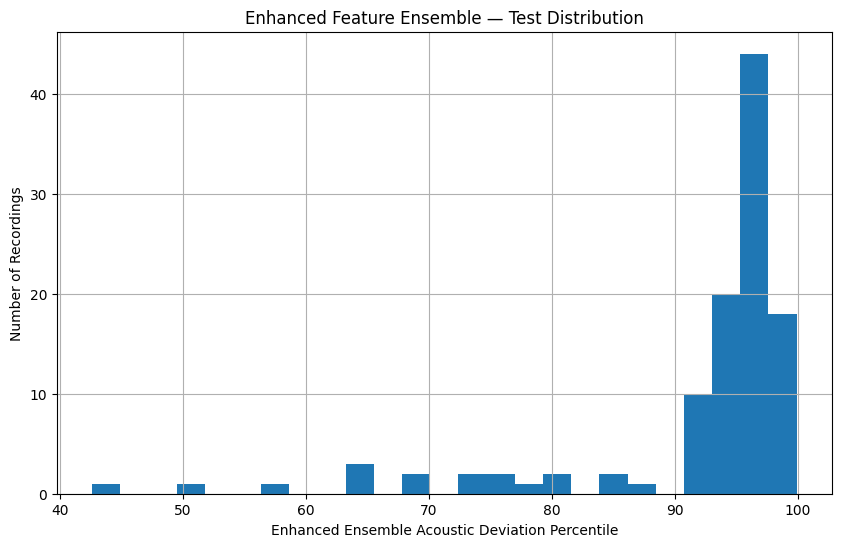

In [ ]:
plt.figure(figsize=(10, 6))

plt.hist(
    enhanced_test_scores_df["ensemble_pct"],
    bins=25
)

plt.xlabel(
    "Enhanced Ensemble Acoustic Deviation Percentile"
)

plt.ylabel(
    "Number of Recordings"
)

plt.title(
    "Enhanced Feature Ensemble — Test Distribution"
)

plt.grid(True)

plt.show()

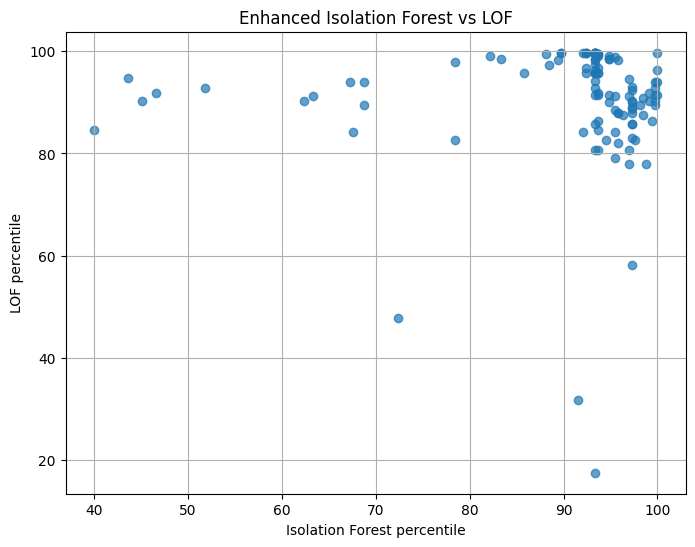

In [ ]:
plt.figure(figsize=(8, 6))

plt.scatter(
    enhanced_test_scores_df[
        "isolation_forest_pct"
    ],
    enhanced_test_scores_df[
        "lof_pct"
    ],
    alpha=0.7
)

plt.xlabel(
    "Isolation Forest percentile"
)

plt.ylabel(
    "LOF percentile"
)

plt.title(
    "Enhanced Isolation Forest vs LOF"
)

plt.grid(True)

plt.show()

In [ ]:
# ==========================================
# ENHANCED MODEL CORRELATION
# ==========================================

enhanced_correlation = (
    enhanced_test_scores_df[
        [
            "isolation_forest_pct",
            "lof_pct",
            "svm_pct"
        ]
    ]
    .corr()
    .round(3)
)

print(enhanced_correlation)

                      isolation_forest_pct  lof_pct  svm_pct
isolation_forest_pct                 1.000    0.016    0.858
lof_pct                              0.016    1.000    0.142
svm_pct                              0.858    0.142    1.000


In [ ]:
# ==========================================
# ENHANCED VALIDATION ENSEMBLE
# ==========================================

enhanced_validation_scores_df = pd.DataFrame({

    "audio_file": enhanced_background_features_df.loc[
        enhanced_valid_mask,
        "audio_file"
    ].values,

    "isolation_forest_pct": enhanced_if_valid_pct,

    "lof_pct": enhanced_lof_valid_pct,

    "svm_pct": enhanced_svm_valid_pct
})

# Equal-weight ensemble
enhanced_validation_scores_df["ensemble_pct"] = (
    enhanced_validation_scores_df[
        [
            "isolation_forest_pct",
            "lof_pct",
            "svm_pct"
        ]
    ].mean(axis=1)
)

# Model consensus
enhanced_validation_scores_df["models_above_90"] = (
    enhanced_validation_scores_df[
        [
            "isolation_forest_pct",
            "lof_pct",
            "svm_pct"
        ]
    ] >= 90
).sum(axis=1)

print(
    "Enhanced validation ensemble percentiles:"
)

print(
    np.percentile(
        enhanced_validation_scores_df["ensemble_pct"],
        [50, 75, 90, 95, 99]
    )
)

print("\nEnhanced validation model consensus:")

print(
    enhanced_validation_scores_df[
        "models_above_90"
    ].value_counts().sort_index()
)

Enhanced validation ensemble percentiles:
[95.85858586 96.84343434 97.28282828 97.53030303 98.44848485]

Enhanced validation model consensus:
models_above_90
0     2
1     2
2    48
3    58
Name: count, dtype: int64


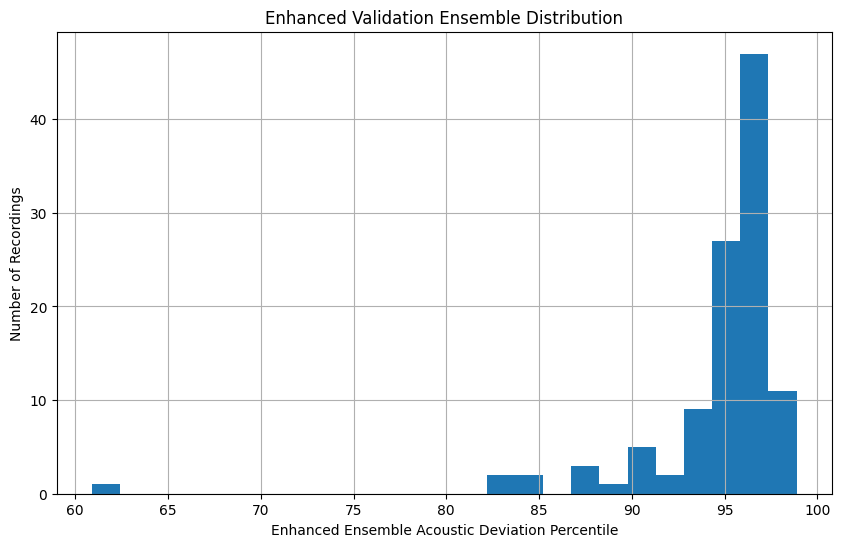

In [ ]:
# ==========================================
# ENHANCED VALIDATION DISTRIBUTION
# ==========================================

plt.figure(figsize=(10, 6))

plt.hist(
    enhanced_validation_scores_df["ensemble_pct"],
    bins=25
)

plt.xlabel(
    "Enhanced Ensemble Acoustic Deviation Percentile"
)

plt.ylabel(
    "Number of Recordings"
)

plt.title(
    "Enhanced Validation Ensemble Distribution"
)

plt.grid(True)

plt.show()

In [ ]:
# ==========================================
# ENHANCED VALIDATION TOP CANDIDATES
# ==========================================

enhanced_validation_top = (
    enhanced_validation_scores_df
    .sort_values(
        "ensemble_pct",
        ascending=False
    )
    .head(15)
)

enhanced_validation_top

,audio_file,isolation_forest_pct,lof_pct,svm_pct,ensemble_pct,models_above_90
4,SONYC-Backgrounds/valid/14_2017-05-18_05_00.wav,100.000000,96.666667,100.0,98.888889,3
91,SONYC-Backgrounds/valid/14_2017-04-30_05_00.wav,100.000000,95.454545,100.0,98.484848,3
11,SONYC-Backgrounds/valid/17_2017-05-28_07_00.wav,94.848485,99.393939,100.0,98.080808,3
19,SONYC-Backgrounds/valid/37_2017-06-09_05_00.wav,97.272727,95.757576,100.0,97.676768,3
69,SONYC-Backgrounds/valid/14_2017-05-14_17_00.wav,97.272727,95.757576,100.0,97.676768,3
23,SONYC-Backgrounds/valid/14_2017-05-17_05_00.wav,100.000000,92.727273,100.0,97.575758,3
50,SONYC-Backgrounds/valid/14_2017-05-03_05_00.wav,100.000000,92.424242,100.0,97.474747,3
85,SONYC-Backgrounds/valid/14_2017-05-20_05_00.wav,100.000000,92.424242,100.0,97.474747,3
36,SONYC-Backgrounds/valid/14_2017-05-16_04_00.wav,100.000000,92.424242,100.0,97.474747,3
34,SONYC-Backgrounds/valid/06_2017-05-28_05_00.wav,99.696970,92.424242,100.0,97.373737,3


In [ ]:
# ==========================================
# CALIBRATE ENHANCED DEVIATION LEVELS
# ==========================================

# Thresholds learned from validation distribution

moderate_threshold = np.percentile(
    enhanced_validation_scores_df["ensemble_pct"],
    90
)

high_threshold = np.percentile(
    enhanced_validation_scores_df["ensemble_pct"],
    95
)

extreme_threshold = np.percentile(
    enhanced_validation_scores_df["ensemble_pct"],
    99
)

print("Moderate threshold:", moderate_threshold)
print("High threshold:", high_threshold)
print("Extreme threshold:", extreme_threshold)

Moderate threshold: 97.28282828282828
High threshold: 97.53030303030303
Extreme threshold: 98.44848484848485


In [ ]:
# ==========================================
# DEVIATION SEVERITY
# ==========================================

def enhanced_deviation_level(score):

    if score >= extreme_threshold:
        return "Extreme Deviation"

    elif score >= high_threshold:
        return "High Deviation"

    elif score >= moderate_threshold:
        return "Moderate Deviation"

    else:
        return "Normal Variation"


enhanced_validation_scores_df["deviation_level"] = (
    enhanced_validation_scores_df["ensemble_pct"]
    .apply(enhanced_deviation_level)
)

print(
    enhanced_validation_scores_df[
        "deviation_level"
    ].value_counts()
)

deviation_level
Normal Variation      99
Moderate Deviation     5
High Deviation         4
Extreme Deviation      2
Name: count, dtype: int64


In [ ]:
# ==========================================
# FINAL TEST DEVIATION LEVELS
# ==========================================

enhanced_test_scores_df["deviation_level"] = (
    enhanced_test_scores_df["ensemble_pct"]
    .apply(enhanced_deviation_level)
)

print(
    enhanced_test_scores_df[
        "deviation_level"
    ].value_counts()
)

deviation_level
Normal Variation      86
High Deviation        18
Moderate Deviation     4
Extreme Deviation      2
Name: count, dtype: int64


In [ ]:
print(
    enhanced_test_scores_df[
        [
            "ensemble_pct",
            "models_above_90",
            "deviation_level"
        ]
    ].describe()
)

       ensemble_pct  models_above_90
count    110.000000       110.000000
mean      91.752066         2.336364
std       10.551465         0.815866
min       42.626263         0.000000
25%       92.803030         2.000000
50%       95.808081         3.000000
75%       97.171717         3.000000
max       99.898990         3.000000


In [ ]:
# ==========================================
# FINAL TOP ANOMALY CANDIDATES
# ==========================================

final_top_candidates = (
    enhanced_test_scores_df
    .sort_values(
        "ensemble_pct",
        ascending=False
    )
    .head(20)
)

final_top_candidates[
    [
        "audio_file",
        "isolation_forest_pct",
        "lof_pct",
        "svm_pct",
        "ensemble_pct",
        "models_above_90",
        "deviation_level"
    ]
]

,audio_file,isolation_forest_pct,lof_pct,svm_pct,ensemble_pct,models_above_90,deviation_level
51,SONYC-Backgrounds/test/08_2017-05-14_05_00.wav,100.000000,99.696970,100.0,99.898990,3,Extreme Deviation
0,SONYC-Backgrounds/test/31_2017-05-18_05_01.wav,100.000000,96.363636,100.0,98.787879,3,Extreme Deviation
29,SONYC-Backgrounds/test/04_2017-06-19_04_02.wav,95.454545,98.787879,100.0,98.080808,3,High Deviation
41,SONYC-Backgrounds/test/04_2017-07-18_06_00.wav,95.757576,98.181818,100.0,97.979798,3,High Deviation
77,SONYC-Backgrounds/test/08_2017-05-28_16_00.wav,100.000000,93.939394,100.0,97.979798,3,High Deviation
103,SONYC-Backgrounds/test/04_2017-07-23_07_00.wav,94.848485,99.090909,100.0,97.979798,3,High Deviation
101,SONYC-Backgrounds/test/31_2017-04-16_05_00.wav,99.696970,93.939394,100.0,97.878788,3,High Deviation
57,SONYC-Backgrounds/test/04_2017-08-03_05_00.wav,94.848485,98.484848,100.0,97.777778,3,High Deviation
48,SONYC-Backgrounds/test/04_2017-07-15_06_01.wav,94.848485,98.484848,100.0,97.777778,3,High Deviation
62,SONYC-Backgrounds/test/04_2017-07-21_03_00.wav,93.333333,99.696970,100.0,97.676768,3,High Deviation


In [ ]:
# ==========================================
# PCA RECONSTRUCTION ANOMALY DETECTOR
# ==========================================

from sklearn.decomposition import PCA

# Use the PCA that already retains 95% variance
# and was fitted only on training data

pca_reconstruction = PCA(
    n_components=13
)

# Fit ONLY on training data
X_train_pca = pca_reconstruction.fit_transform(
    X_enhanced_train_scaled
)

# Transform validation and test
X_valid_pca = pca_reconstruction.transform(
    X_enhanced_valid_scaled
)

X_test_pca = pca_reconstruction.transform(
    X_enhanced_test_scaled
)

print("Training PCA:", X_train_pca.shape)
print("Validation PCA:", X_valid_pca.shape)
print("Test PCA:", X_test_pca.shape)

print(
    "Variance retained:",
    pca_reconstruction.explained_variance_ratio_.sum()
)

Training PCA: (330, 13)
Validation PCA: (110, 13)
Test PCA: (110, 13)
Variance retained: 0.9532421132551279


In [ ]:
# ==========================================
# RECONSTRUCT ORIGINAL FEATURES
# ==========================================

X_train_reconstructed = (
    pca_reconstruction.inverse_transform(
        X_train_pca
    )
)

X_valid_reconstructed = (
    pca_reconstruction.inverse_transform(
        X_valid_pca
    )
)

X_test_reconstructed = (
    pca_reconstruction.inverse_transform(
        X_test_pca
    )
)

print(
    "Reconstructed training shape:",
    X_train_reconstructed.shape
)

print(
    "Reconstructed validation shape:",
    X_valid_reconstructed.shape
)

print(
    "Reconstructed test shape:",
    X_test_reconstructed.shape
)


Reconstructed training shape: (330, 126)
Reconstructed validation shape: (110, 126)
Reconstructed test shape: (110, 126)


In [ ]:
# ==========================================
# PCA RECONSTRUCTION ERROR
# ==========================================

train_reconstruction_error = np.mean(
    (
        X_enhanced_train_scaled
        - X_train_reconstructed
    ) ** 2,
    axis=1
)

valid_reconstruction_error = np.mean(
    (
        X_enhanced_valid_scaled
        - X_valid_reconstructed
    ) ** 2,
    axis=1
)

test_reconstruction_error = np.mean(
    (
        X_enhanced_test_scaled
        - X_test_reconstructed
    ) ** 2,
    axis=1
)

print(
    "Training error:",
    train_reconstruction_error.min(),
    "to",
    train_reconstruction_error.max()
)

print(
    "Validation error:",
    valid_reconstruction_error.min(),
    "to",
    valid_reconstruction_error.max()
)

print(
    "Test error:",
    test_reconstruction_error.min(),
    "to",
    test_reconstruction_error.max()
)

Training error: 0.005822426123724653 to 0.3505504134158515
Validation error: 0.062310721150310173 to 0.7197724069652254
Test error: 0.027995147509875914 to 0.7367034714316317


In [ ]:
# ==========================================
# PCA RECONSTRUCTION PERCENTILES
# ==========================================

pca_valid_pct = percentile_scores(
    train_reconstruction_error,
    valid_reconstruction_error
)

pca_test_pct = percentile_scores(
    train_reconstruction_error,
    test_reconstruction_error
)

print(
    "PCA validation percentile:",
    pca_valid_pct.min(),
    "to",
    pca_valid_pct.max()
)

print(
    "PCA test percentile:",
    pca_test_pct.min(),
    "to",
    pca_test_pct.max()
)

PCA validation percentile: 79.6969696969697 to 100.0
PCA test percentile: 40.303030303030305 to 100.0


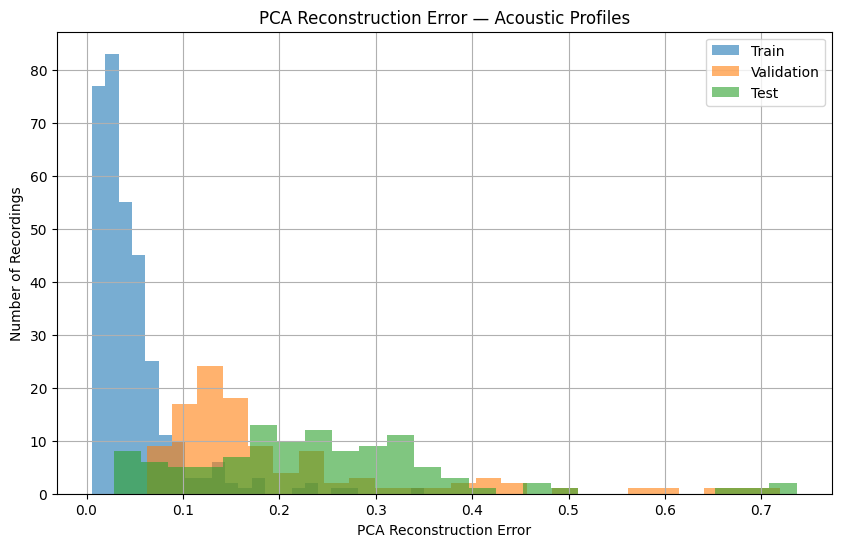

In [ ]:
# ==========================================
# PCA RECONSTRUCTION ERROR DISTRIBUTION
# ==========================================

plt.figure(figsize=(10, 6))

plt.hist(
    train_reconstruction_error,
    bins=25,
    alpha=0.6,
    label="Train"
)

plt.hist(
    valid_reconstruction_error,
    bins=25,
    alpha=0.6,
    label="Validation"
)

plt.hist(
    test_reconstruction_error,
    bins=25,
    alpha=0.6,
    label="Test"
)

plt.xlabel("PCA Reconstruction Error")
plt.ylabel("Number of Recordings")

plt.title(
    "PCA Reconstruction Error — Acoustic Profiles"
)

plt.legend()
plt.grid(True)

plt.show()

In [ ]:
# ==========================================
# FOUR-MODEL ANOMALY TABLE
# ==========================================

final_test_scores_df = pd.DataFrame({

    "audio_file":
        enhanced_background_features_df.loc[
            enhanced_test_mask,
            "audio_file"
        ].values,

    "isolation_forest_pct":
        enhanced_if_test_pct,

    "lof_pct":
        enhanced_lof_test_pct,

    "svm_pct":
        enhanced_svm_test_pct,

    "pca_reconstruction_pct":
        pca_test_pct
})

print(
    final_test_scores_df.head()
)

                                       audio_file  isolation_forest_pct  \
0  SONYC-Backgrounds/test/31_2017-05-18_05_01.wav            100.000000   
1  SONYC-Backgrounds/test/04_2017-07-19_04_00.wav             93.333333   
2  SONYC-Backgrounds/test/04_2017-04-24_05_00.wav             93.636364   
3  SONYC-Backgrounds/test/02_2017-12-31_04_00.wav             51.818182   
4  SONYC-Backgrounds/test/04_2017-07-02_05_00.wav             98.484848   

     lof_pct  svm_pct  pca_reconstruction_pct  
0  96.363636    100.0              100.000000  
1  99.696970    100.0               99.696970  
2  91.515152    100.0               95.757576  
3  92.727273     60.0               98.181818  
4  87.575758    100.0              100.000000  


In [ ]:
# ==========================================
# FOUR-MODEL ENSEMBLE
# ==========================================

final_test_scores_df["ensemble_pct"] = (
    final_test_scores_df[
        [
            "isolation_forest_pct",
            "lof_pct",
            "svm_pct",
            "pca_reconstruction_pct"
        ]
    ].mean(axis=1)
)

# Number of models above 90
final_test_scores_df["models_above_90"] = (
    final_test_scores_df[
        [
            "isolation_forest_pct",
            "lof_pct",
            "svm_pct",
            "pca_reconstruction_pct"
        ]
    ] >= 90
).sum(axis=1)

print(
    final_test_scores_df.head()
)

                                       audio_file  isolation_forest_pct  \
0  SONYC-Backgrounds/test/31_2017-05-18_05_01.wav            100.000000   
1  SONYC-Backgrounds/test/04_2017-07-19_04_00.wav             93.333333   
2  SONYC-Backgrounds/test/04_2017-04-24_05_00.wav             93.636364   
3  SONYC-Backgrounds/test/02_2017-12-31_04_00.wav             51.818182   
4  SONYC-Backgrounds/test/04_2017-07-02_05_00.wav             98.484848   

     lof_pct  svm_pct  pca_reconstruction_pct  ensemble_pct  models_above_90  
0  96.363636    100.0              100.000000     99.090909                4  
1  99.696970    100.0               99.696970     98.181818                4  
2  91.515152    100.0               95.757576     95.227273                4  
3  92.727273     60.0               98.181818     75.681818                2  
4  87.575758    100.0              100.000000     96.515152                3  


In [ ]:
# ==========================================
# FOUR-MODEL VALIDATION ENSEMBLE
# ==========================================

final_validation_scores_df = pd.DataFrame({

    "audio_file":
        enhanced_background_features_df.loc[
            enhanced_valid_mask,
            "audio_file"
        ].values,

    "isolation_forest_pct":
        enhanced_if_valid_pct,

    "lof_pct":
        enhanced_lof_valid_pct,

    "svm_pct":
        enhanced_svm_valid_pct,

    "pca_reconstruction_pct":
        pca_valid_pct
})

# Four-model equal-weight ensemble

final_validation_scores_df["ensemble_pct"] = (
    final_validation_scores_df[
        [
            "isolation_forest_pct",
            "lof_pct",
            "svm_pct",
            "pca_reconstruction_pct"
        ]
    ].mean(axis=1)
)

# Model consensus

final_validation_scores_df["models_above_90"] = (
    final_validation_scores_df[
        [
            "isolation_forest_pct",
            "lof_pct",
            "svm_pct",
            "pca_reconstruction_pct"
        ]
    ] >= 90
).sum(axis=1)

print("Four-model validation percentiles:")

print(
    np.percentile(
        final_validation_scores_df["ensemble_pct"],
        [50, 75, 90, 95, 99]
    )
)

print("\nFour-model validation consensus:")

print(
    final_validation_scores_df[
        "models_above_90"
    ].value_counts().sort_index()
)

Four-model validation percentiles:
[96.02272727 96.66666667 97.1969697  97.92045455 98.4780303 ]

Four-model validation consensus:
models_above_90
0     1
1     1
2     7
3    47
4    54
Name: count, dtype: int64


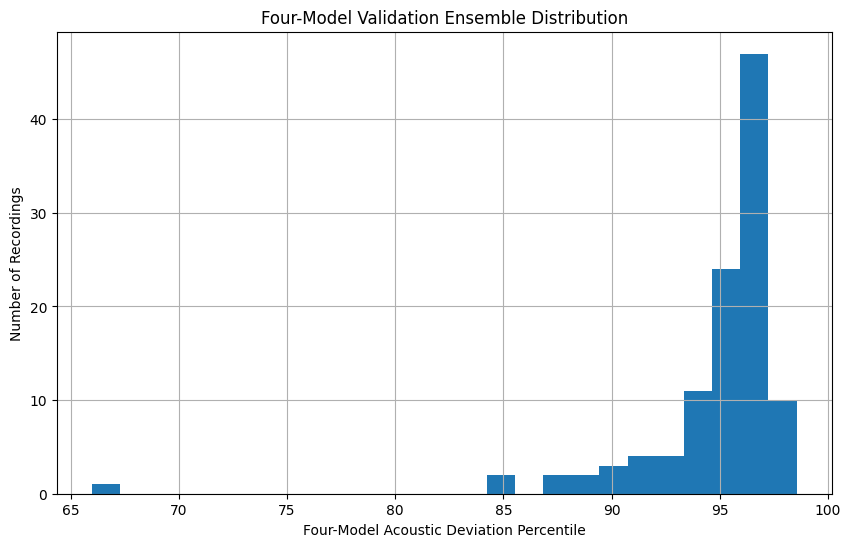

In [ ]:
# ==========================================
# FOUR-MODEL VALIDATION DISTRIBUTION
# ==========================================

plt.figure(figsize=(10, 6))

plt.hist(
    final_validation_scores_df["ensemble_pct"],
    bins=25
)

plt.xlabel(
    "Four-Model Acoustic Deviation Percentile"
)

plt.ylabel("Number of Recordings")

plt.title(
    "Four-Model Validation Ensemble Distribution"
)

plt.grid(True)

plt.show()

In [ ]:
# ==========================================
# VALIDATION TOP CANDIDATES
# ==========================================

final_validation_top = (
    final_validation_scores_df
    .sort_values(
        "ensemble_pct",
        ascending=False
    )
    .head(15)
)

final_validation_top[
    [
        "audio_file",
        "isolation_forest_pct",
        "lof_pct",
        "svm_pct",
        "pca_reconstruction_pct",
        "ensemble_pct",
        "models_above_90"
    ]
]

,audio_file,isolation_forest_pct,lof_pct,svm_pct,pca_reconstruction_pct,ensemble_pct,models_above_90
11,SONYC-Backgrounds/valid/17_2017-05-28_07_00.wav,94.848485,99.393939,100.0,100.000000,98.560606,4
4,SONYC-Backgrounds/valid/14_2017-05-18_05_00.wav,100.000000,96.666667,100.0,97.272727,98.484848,4
91,SONYC-Backgrounds/valid/14_2017-04-30_05_00.wav,100.000000,95.454545,100.0,98.181818,98.409091,4
19,SONYC-Backgrounds/valid/37_2017-06-09_05_00.wav,97.272727,95.757576,100.0,100.000000,98.257576,4
62,SONYC-Backgrounds/valid/37_2017-04-17_06_00.wav,95.454545,96.363636,100.0,100.000000,97.954545,4
90,SONYC-Backgrounds/valid/14_2017-05-14_14_00.wav,97.272727,94.545455,100.0,100.000000,97.954545,4
74,SONYC-Backgrounds/valid/19_2017-06-15_06_00.wav,99.090909,92.424242,100.0,100.000000,97.878788,4
59,SONYC-Backgrounds/valid/14_2017-04-15_05_00.wav,100.000000,91.515152,100.0,99.090909,97.651515,4
65,SONYC-Backgrounds/valid/37_2017-01-30_06_00.wav,93.636364,97.878788,100.0,98.181818,97.424242,4
50,SONYC-Backgrounds/valid/14_2017-05-03_05_00.wav,100.000000,92.424242,100.0,96.969697,97.348485,4


In [ ]:
# ==========================================
# FINAL FOUR-MODEL THRESHOLD CALIBRATION
# ==========================================

moderate_threshold_4model = np.percentile(
    final_validation_scores_df["ensemble_pct"],
    90
)

high_threshold_4model = np.percentile(
    final_validation_scores_df["ensemble_pct"],
    95
)

extreme_threshold_4model = np.percentile(
    final_validation_scores_df["ensemble_pct"],
    99
)

print("Final Moderate threshold:",
      moderate_threshold_4model)

print("Final High threshold:",
      high_threshold_4model)

print("Final Extreme threshold:",
      extreme_threshold_4model)

Final Moderate threshold: 97.1969696969697
Final High threshold: 97.92045454545455
Final Extreme threshold: 98.47803030303031


In [ ]:
# ==========================================
# FINAL DEVIATION SEVERITY
# ==========================================

def final_deviation_level(score):

    if score >= extreme_threshold_4model:
        return "Extreme Deviation"

    elif score >= high_threshold_4model:
        return "High Deviation"

    elif score >= moderate_threshold_4model:
        return "Moderate Deviation"

    else:
        return "Normal Variation"

In [ ]:
# ==========================================
# VALIDATION SEVERITY CHECK
# ==========================================

final_validation_scores_df["deviation_level"] = (
    final_validation_scores_df["ensemble_pct"]
    .apply(final_deviation_level)
)

print(
    final_validation_scores_df[
        "deviation_level"
    ].value_counts()
)

deviation_level
Normal Variation      96
Moderate Deviation     8
High Deviation         4
Extreme Deviation      2
Name: count, dtype: int64


In [ ]:
# ==========================================
# FINAL TEST DEVIATION LEVELS
# ==========================================

final_test_scores_df["deviation_level"] = (
    final_test_scores_df["ensemble_pct"]
    .apply(final_deviation_level)
)

print(
    final_test_scores_df[
        "deviation_level"
    ].value_counts()
)

deviation_level
Normal Variation      76
High Deviation        20
Moderate Deviation    10
Extreme Deviation      4
Name: count, dtype: int64


In [ ]:
# ==========================================
# FINAL ANOMALY SCORE
# ==========================================

final_test_scores_df["anomaly_score"] = (
    final_test_scores_df["ensemble_pct"]
)

final_test_scores_df[
    [
        "audio_file",
        "ensemble_pct",
        "models_above_90",
        "deviation_level",
        "anomaly_score"
    ]
].head(10)

,audio_file,ensemble_pct,models_above_90,deviation_level,anomaly_score
0,SONYC-Backgrounds/test/31_2017-05-18_05_01.wav,99.090909,4,Extreme Deviation,99.090909
1,SONYC-Backgrounds/test/04_2017-07-19_04_00.wav,98.181818,4,High Deviation,98.181818
2,SONYC-Backgrounds/test/04_2017-04-24_05_00.wav,95.227273,4,Normal Variation,95.227273
3,SONYC-Backgrounds/test/02_2017-12-31_04_00.wav,75.681818,2,Normal Variation,75.681818
4,SONYC-Backgrounds/test/04_2017-07-02_05_00.wav,96.515152,3,Normal Variation,96.515152
5,SONYC-Backgrounds/test/04_2017-07-15_05_00.wav,96.515152,3,Normal Variation,96.515152
6,SONYC-Backgrounds/test/08_2017-05-14_06_00.wav,95.000000,3,Normal Variation,95.000000
7,SONYC-Backgrounds/test/31_2017-05-19_04_00.wav,70.303030,1,Normal Variation,70.303030
8,SONYC-Backgrounds/test/31_2017-03-16_01_00.wav,83.560606,2,Normal Variation,83.560606
9,SONYC-Backgrounds/test/04_2017-07-08_05_00.wav,96.363636,4,Normal Variation,96.363636


In [ ]:
# ==========================================
# FINAL ANOMALY RANKING
# ==========================================

final_anomaly_ranking = (
    final_test_scores_df
    .sort_values(
        ["ensemble_pct", "models_above_90"],
        ascending=[False, False]
    )
    .reset_index(drop=True)
)

final_anomaly_ranking[
    [
        "audio_file",
        "isolation_forest_pct",
        "lof_pct",
        "svm_pct",
        "pca_reconstruction_pct",
        "ensemble_pct",
        "models_above_90",
        "deviation_level"
    ]
].head(20)

,audio_file,isolation_forest_pct,lof_pct,svm_pct,pca_reconstruction_pct,ensemble_pct,models_above_90,deviation_level
0,SONYC-Backgrounds/test/08_2017-05-14_05_00.wav,100.000000,99.696970,100.0,100.000000,99.924242,4,Extreme Deviation
1,SONYC-Backgrounds/test/31_2017-05-18_05_01.wav,100.000000,96.363636,100.0,100.000000,99.090909,4,Extreme Deviation
2,SONYC-Backgrounds/test/04_2017-06-19_04_02.wav,95.454545,98.787879,100.0,99.696970,98.484848,4,Extreme Deviation
3,SONYC-Backgrounds/test/08_2017-05-28_16_00.wav,100.000000,93.939394,100.0,100.000000,98.484848,4,Extreme Deviation
4,SONYC-Backgrounds/test/31_2017-04-16_05_00.wav,99.696970,93.939394,100.0,100.000000,98.409091,4,High Deviation
5,SONYC-Backgrounds/test/04_2017-07-13_03_00.wav,93.333333,99.696970,100.0,100.000000,98.257576,4,High Deviation
6,SONYC-Backgrounds/test/04_2017-07-18_06_00.wav,95.757576,98.181818,100.0,99.090909,98.257576,4,High Deviation
7,SONYC-Backgrounds/test/04_2017-07-15_06_01.wav,94.848485,98.484848,100.0,99.696970,98.257576,4,High Deviation
8,SONYC-Backgrounds/test/04_2017-08-03_05_00.wav,94.848485,98.484848,100.0,99.696970,98.257576,4,High Deviation
9,SONYC-Backgrounds/test/04_2017-07-19_04_00.wav,93.333333,99.696970,100.0,99.696970,98.181818,4,High Deviation


In [ ]:
# ==========================================
# CREATE FINAL MASTER ANOMALY DATASET
# ==========================================

final_master_df = final_test_scores_df.copy()

# Extract filename
final_master_df["file_name"] = (
    final_master_df["audio_file"]
    .apply(os.path.basename)
)

# Extract sensor ID
final_master_df["sensor_id"] = (
    final_master_df["file_name"]
    .str.extract(r"^(\d+)_")[0]
    .astype(int)
)

# Extract date
final_master_df["date"] = pd.to_datetime(
    final_master_df["file_name"]
    .str.extract(r"_(\d{4}-\d{2}-\d{2})_")[0]
)

# Extract hour
final_master_df["hour"] = (
    final_master_df["file_name"]
    .str.extract(r"_(\d{2})_\d{2}\.wav$")[0]
    .astype(int)
)

# Calendar fields
final_master_df["year"] = (
    final_master_df["date"].dt.year
)

final_master_df["month"] = (
    final_master_df["date"].dt.month
)

final_master_df["day"] = (
    final_master_df["date"].dt.day
)

# Split
final_master_df["split"] = "test"

# Display
final_master_df.head()

,audio_file,isolation_forest_pct,lof_pct,svm_pct,pca_reconstruction_pct,ensemble_pct,models_above_90,deviation_level,anomaly_score,file_name,sensor_id,date,hour,year,month,day,split
0,SONYC-Backgrounds/test/31_2017-05-18_05_01.wav,100.000000,96.363636,100.0,100.000000,99.090909,4,Extreme Deviation,99.090909,31_2017-05-18_05_01.wav,31,2017-05-18,5,2017,5,18,test
1,SONYC-Backgrounds/test/04_2017-07-19_04_00.wav,93.333333,99.696970,100.0,99.696970,98.181818,4,High Deviation,98.181818,04_2017-07-19_04_00.wav,4,2017-07-19,4,2017,7,19,test
2,SONYC-Backgrounds/test/04_2017-04-24_05_00.wav,93.636364,91.515152,100.0,95.757576,95.227273,4,Normal Variation,95.227273,04_2017-04-24_05_00.wav,4,2017-04-24,5,2017,4,24,test
3,SONYC-Backgrounds/test/02_2017-12-31_04_00.wav,51.818182,92.727273,60.0,98.181818,75.681818,2,Normal Variation,75.681818,02_2017-12-31_04_00.wav,2,2017-12-31,4,2017,12,31,test
4,SONYC-Backgrounds/test/04_2017-07-02_05_00.wav,98.484848,87.575758,100.0,100.000000,96.515152,3,Normal Variation,96.515152,04_2017-07-02_05_00.wav,4,2017-07-02,5,2017,7,2,test


In [ ]:
print("Final master shape:")
print(final_master_df.shape)

print("\nColumns:")
print(final_master_df.columns.tolist())

Final master shape:
(110, 17)

Columns:
['audio_file', 'isolation_forest_pct', 'lof_pct', 'svm_pct', 'pca_reconstruction_pct', 'ensemble_pct', 'models_above_90', 'deviation_level', 'anomaly_score', 'file_name', 'sensor_id', 'date', 'hour', 'year', 'month', 'day', 'split']


In [ ]:
print(
    final_master_df[
        [
            "file_name",
            "sensor_id",
            "date",
            "hour",
            "isolation_forest_pct",
            "lof_pct",
            "svm_pct",
            "pca_reconstruction_pct",
            "ensemble_pct",
            "models_above_90",
            "deviation_level"
        ]
    ].head(10)
)

                 file_name  sensor_id       date  hour  isolation_forest_pct  \
0  31_2017-05-18_05_01.wav         31 2017-05-18     5            100.000000   
1  04_2017-07-19_04_00.wav          4 2017-07-19     4             93.333333   
2  04_2017-04-24_05_00.wav          4 2017-04-24     5             93.636364   
3  02_2017-12-31_04_00.wav          2 2017-12-31     4             51.818182   
4  04_2017-07-02_05_00.wav          4 2017-07-02     5             98.484848   
5  04_2017-07-15_05_00.wav          4 2017-07-15     5             97.272727   
6  08_2017-05-14_06_00.wav          8 2017-05-14     6             83.333333   
7  31_2017-05-19_04_00.wav         31 2017-05-19     4             67.272727   
8  31_2017-03-16_01_00.wav         31 2017-03-16     1             68.787879   
9  04_2017-07-08_05_00.wav          4 2017-07-08     5             97.272727   

     lof_pct     svm_pct  pca_reconstruction_pct  ensemble_pct  \
0  96.363636  100.000000              100.000000     

In [ ]:
# ==========================================
# CREATE STABLE RECORDING ID
# ==========================================

final_master_df["recording_id"] = (
    final_master_df["file_name"]
    .str.replace(".wav", "", regex=False)
)

print(
    final_master_df[
        [
            "recording_id",
            "file_name",
            "sensor_id",
            "date",
            "hour",
            "ensemble_pct",
            "deviation_level"
        ]
    ].head(10)
)

          recording_id                file_name  sensor_id       date  hour  \
0  31_2017-05-18_05_01  31_2017-05-18_05_01.wav         31 2017-05-18     5   
1  04_2017-07-19_04_00  04_2017-07-19_04_00.wav          4 2017-07-19     4   
2  04_2017-04-24_05_00  04_2017-04-24_05_00.wav          4 2017-04-24     5   
3  02_2017-12-31_04_00  02_2017-12-31_04_00.wav          2 2017-12-31     4   
4  04_2017-07-02_05_00  04_2017-07-02_05_00.wav          4 2017-07-02     5   
5  04_2017-07-15_05_00  04_2017-07-15_05_00.wav          4 2017-07-15     5   
6  08_2017-05-14_06_00  08_2017-05-14_06_00.wav          8 2017-05-14     6   
7  31_2017-05-19_04_00  31_2017-05-19_04_00.wav         31 2017-05-19     4   
8  31_2017-03-16_01_00  31_2017-03-16_01_00.wav         31 2017-03-16     1   
9  04_2017-07-08_05_00  04_2017-07-08_05_00.wav          4 2017-07-08     5   

   ensemble_pct    deviation_level  
0     99.090909  Extreme Deviation  
1     98.181818     High Deviation  
2     95.227273   N

In [ ]:
# ==========================================
# RECORDING ID QUALITY CHECK
# ==========================================

print(
    "Unique recording IDs:",
    final_master_df["recording_id"].nunique()
)

print(
    "Total recordings:",
    len(final_master_df)
)

print(
    "Duplicate recording IDs:",
    final_master_df["recording_id"].duplicated().sum()
)

Unique recording IDs: 110
Total recordings: 110
Duplicate recording IDs: 0


In [ ]:
# ==========================================
# INSTALL MYSQL CONNECTOR
# ==========================================

!pip install mysql-connector-python

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.7/21.7 MB 58.0 MB/s eta 0:00:00


In [ ]:
import mysql.connector

print("MySQL connector imported successfully!")
print("Connector version:", mysql.connector.__version__)

MySQL connector imported successfully!
Connector version: 26.7.0


In [ ]:
recordings_df = final_master_df[
    [
        "recording_id",
        "file_name",
        "sensor_id",
        "date",
        "hour",
        "year",
        "month",
        "day",
        "split"
    ]
].copy()

# Rename date column to match MySQL
recordings_df.rename(
    columns={"date": "recording_date"},
    inplace=True
)

# Check the result
print(recordings_df.shape)
display(recordings_df.head())

(110, 9)


,recording_id,file_name,sensor_id,recording_date,hour,year,month,day,split
0,31_2017-05-18_05_01,31_2017-05-18_05_01.wav,31,2017-05-18,5,2017,5,18,test
1,04_2017-07-19_04_00,04_2017-07-19_04_00.wav,4,2017-07-19,4,2017,7,19,test
2,04_2017-04-24_05_00,04_2017-04-24_05_00.wav,4,2017-04-24,5,2017,4,24,test
3,02_2017-12-31_04_00,02_2017-12-31_04_00.wav,2,2017-12-31,4,2017,12,31,test
4,04_2017-07-02_05_00,04_2017-07-02_05_00.wav,4,2017-07-02,5,2017,7,2,test


In [ ]:
recordings_df.to_csv(
    "recordings.csv",
    index=False
)

print("recordings.csv created successfully")

recordings.csv created successfully


In [ ]:
# Check our enhanced feature dataframe
print(enhanced_background_features_df.shape)

print("\nFirst 10 columns:")
print(enhanced_background_features_df.columns[:10].tolist())

print("\nLast 10 columns:")
print(enhanced_background_features_df.columns[-10:].tolist())

(550, 134)

First 10 columns:
['rms_mean', 'rms_std', 'rms_p10', 'rms_p25', 'rms_median', 'rms_p75', 'rms_p90', 'zcr_mean', 'zcr_std', 'zcr_p10']

Last 10 columns:
['mfcc_13_p75', 'mfcc_13_p90', 'audio_file', 'split', 'sensor_id', 'date', 'year', 'month', 'day', 'hour']


In [ ]:
# Select only the test recordings
test_features_df = enhanced_background_features_df[
    enhanced_background_features_df["split"] == "test"
].copy()

print("Test feature dataset shape:", test_features_df.shape)

Test feature dataset shape: (110, 134)


In [ ]:
# Select only test recordings
test_features_df = enhanced_background_features_df[
    enhanced_background_features_df["split"] == "test"
].copy()

# Create stable recording ID
test_features_df["recording_id"] = (
    test_features_df["audio_file"]
    .str.replace(".wav", "", regex=False)
)

# Columns that belong to the recordings table, not feature table
metadata_columns = [
    "audio_file",
    "split",
    "sensor_id",
    "date",
    "year",
    "month",
    "day",
    "hour"
]

# Keep recording_id + only acoustic features
feature_columns = [
    col for col in test_features_df.columns
    if col not in metadata_columns + ["recording_id"]
]

acoustic_features_df = test_features_df[
    ["recording_id"] + feature_columns
].copy()

print("Acoustic feature dataset shape:", acoustic_features_df.shape)

print("\nNumber of acoustic features:",
      len(feature_columns))

print("\nFirst 10 columns:")
print(acoustic_features_df.columns[:10].tolist())

print("\nLast 10 columns:")
print(acoustic_features_df.columns[-10:].tolist())

Acoustic feature dataset shape: (110, 127)

Number of acoustic features: 126

First 10 columns:
['recording_id', 'rms_mean', 'rms_std', 'rms_p10', 'rms_p25', 'rms_median', 'rms_p75', 'rms_p90', 'zcr_mean', 'zcr_std']

Last 10 columns:
['mfcc_12_median', 'mfcc_12_p75', 'mfcc_12_p90', 'mfcc_13_mean', 'mfcc_13_std', 'mfcc_13_p10', 'mfcc_13_p25', 'mfcc_13_median', 'mfcc_13_p75', 'mfcc_13_p90']


In [ ]:
print(
    "Duplicate recording IDs:",
    acoustic_features_df["recording_id"].duplicated().sum()
)

Duplicate recording IDs: 0


In [ ]:
display(acoustic_features_df.head())

,recording_id,rms_mean,rms_std,rms_p10,rms_p25,rms_median,rms_p75,rms_p90,zcr_mean,zcr_std,...,mfcc_12_median,mfcc_12_p75,mfcc_12_p90,mfcc_13_mean,mfcc_13_std,mfcc_13_p10,mfcc_13_p25,mfcc_13_median,mfcc_13_p75,mfcc_13_p90
440,SONYC-Backgrounds/test/31_2017-05-18_05_01,0.005902,0.002819,0.003704,0.004307,0.005013,0.006305,0.008736,0.033576,0.021048,...,9.237837,12.362159,15.295405,6.157345,4.867676,0.139614,3.292460,6.170743,9.070440,12.055205
441,SONYC-Backgrounds/test/04_2017-07-19_04_00,0.010196,0.001909,0.007892,0.008878,0.010135,0.011362,0.012682,0.007465,0.004434,...,4.981401,7.471347,9.687420,5.662320,3.812789,0.796394,2.984234,5.668109,8.285144,10.422333
442,SONYC-Backgrounds/test/04_2017-04-24_05_00,0.009583,0.001631,0.007492,0.008460,0.009583,0.010678,0.011722,0.007017,0.005746,...,6.128758,8.906160,11.602831,5.899579,4.184008,0.801858,3.030645,6.003238,8.703902,11.148083
443,SONYC-Backgrounds/test/02_2017-12-31_04_00,0.006195,0.002896,0.003298,0.003974,0.005456,0.007642,0.010899,0.010095,0.009863,...,3.870838,6.644196,9.039033,3.891943,3.585528,-0.713907,1.468775,3.881114,6.410085,8.404750
444,SONYC-Backgrounds/test/04_2017-07-02_05_00,0.010846,0.005801,0.005472,0.006847,0.009176,0.013031,0.018833,0.013068,0.012432,...,9.289978,12.546137,15.209702,4.665983,4.785882,-0.991745,1.759551,4.561250,8.015065,10.528479


In [ ]:
# Remove the dataset path from recording_id
acoustic_features_df["recording_id"] = (
    acoustic_features_df["recording_id"]
    .str.split("/")
    .str[-1]
)

# Verify
print(acoustic_features_df["recording_id"].head())

440    31_2017-05-18_05_01
441    04_2017-07-19_04_00
442    04_2017-04-24_05_00
443    02_2017-12-31_04_00
444    04_2017-07-02_05_00
Name: recording_id, dtype: object


In [ ]:
print("Total feature records:",
      len(acoustic_features_df))

print("Unique feature IDs:",
      acoustic_features_df["recording_id"].nunique())

Total feature records: 110
Unique feature IDs: 110


In [ ]:
recording_ids = set(recordings_df["recording_id"])

feature_ids = set(acoustic_features_df["recording_id"])

print("Feature IDs not in recordings table:",
      len(feature_ids - recording_ids))

print("Recording IDs without features:",
      len(recording_ids - feature_ids))

Feature IDs not in recordings table: 0
Recording IDs without features: 0


In [ ]:
acoustic_features_df.to_csv(
    "acoustic_features.csv",
    index=False
)

print("acoustic_features.csv created successfully")

acoustic_features.csv created successfully


In [ ]:
feature_columns = [
    col for col in acoustic_features_df.columns
    if col != "recording_id"
]

create_table_sql = """
CREATE TABLE acoustic_features (
    recording_id VARCHAR(100) PRIMARY KEY,
"""

for col in feature_columns:
    create_table_sql += f"    `{col}` DOUBLE,\n"

create_table_sql += """
    FOREIGN KEY (recording_id)
        REFERENCES recordings(recording_id)
);
"""

print(create_table_sql)


CREATE TABLE acoustic_features (
    recording_id VARCHAR(100) PRIMARY KEY,
    `rms_mean` DOUBLE,
    `rms_std` DOUBLE,
    `rms_p10` DOUBLE,
    `rms_p25` DOUBLE,
    `rms_median` DOUBLE,
    `rms_p75` DOUBLE,
    `rms_p90` DOUBLE,
    `zcr_mean` DOUBLE,
    `zcr_std` DOUBLE,
    `zcr_p10` DOUBLE,
    `zcr_p25` DOUBLE,
    `zcr_median` DOUBLE,
    `zcr_p75` DOUBLE,
    `zcr_p90` DOUBLE,
    `spectral_centroid_mean` DOUBLE,
    `spectral_centroid_std` DOUBLE,
    `spectral_centroid_p10` DOUBLE,
    `spectral_centroid_p25` DOUBLE,
    `spectral_centroid_median` DOUBLE,
    `spectral_centroid_p75` DOUBLE,
    `spectral_centroid_p90` DOUBLE,
    `spectral_bandwidth_mean` DOUBLE,
    `spectral_bandwidth_std` DOUBLE,
    `spectral_bandwidth_p10` DOUBLE,
    `spectral_bandwidth_p25` DOUBLE,
    `spectral_bandwidth_median` DOUBLE,
    `spectral_bandwidth_p75` DOUBLE,
    `spectral_bandwidth_p90` DOUBLE,
    `spectral_rolloff_mean` DOUBLE,
    `spectral_rolloff_std` DOUBLE,
    `spectral_rol

In [ ]:
anomaly_results_df = final_master_df[
    [
        "recording_id",
        "isolation_forest_pct",
        "lof_pct",
        "svm_pct",
        "pca_reconstruction_pct",
        "ensemble_pct",
        "models_above_90",
        "deviation_level",
        "anomaly_score"
    ]
].copy()

print("Anomaly results shape:", anomaly_results_df.shape)

display(anomaly_results_df.head())

Anomaly results shape: (110, 9)


,recording_id,isolation_forest_pct,lof_pct,svm_pct,pca_reconstruction_pct,ensemble_pct,models_above_90,deviation_level,anomaly_score
0,31_2017-05-18_05_01,100.000000,96.363636,100.0,100.000000,99.090909,4,Extreme Deviation,99.090909
1,04_2017-07-19_04_00,93.333333,99.696970,100.0,99.696970,98.181818,4,High Deviation,98.181818
2,04_2017-04-24_05_00,93.636364,91.515152,100.0,95.757576,95.227273,4,Normal Variation,95.227273
3,02_2017-12-31_04_00,51.818182,92.727273,60.0,98.181818,75.681818,2,Normal Variation,75.681818
4,04_2017-07-02_05_00,98.484848,87.575758,100.0,100.000000,96.515152,3,Normal Variation,96.515152


In [ ]:
print("Duplicate IDs:",
      anomaly_results_df["recording_id"].duplicated().sum())

print("Missing values:",
      anomaly_results_df.isnull().sum().sum())

Duplicate IDs: 0
Missing values: 0


In [ ]:
print(
    anomaly_results_df["deviation_level"].value_counts()
)

deviation_level
Normal Variation      76
High Deviation        20
Moderate Deviation    10
Extreme Deviation      4
Name: count, dtype: int64


In [ ]:
anomaly_results_df.to_csv(
    "anomaly_results.csv",
    index=False
)

print("anomaly_results.csv created successfully")

anomaly_results.csv created successfully
